## **0. Importing necessary librairies**

In [1]:
from astropy.io import fits # for fits file
import matplotlib.pyplot as plt # for data visualisation
import numpy as np # for math and array
import os # to manipulate folder/directory and files
from tqdm import tqdm
# use to not have to type the directory name each time
%cd captures/ 

/Users/lalyboyer/Desktop/software/captures


## **1. Selecting the object**

In [67]:
# variable to select a specific observation
# later on i guess it would be interesting to use it by RA/DEC, only need to change the save_fits() function

OBJECT_NAME = "LAMP_HGAR"
EXPOSURE = 20000
MAX_W, MAX_H = 1936, 1216 # detector pixels

### <span style="color:red">TODO : Remember header fits file metadata</span>.

## **2. Creating the master bias**

Bias-frames are primarily needed to remove the offset value from the images. This is necessary because the offset value is not part of the object signal and is fixed. Therefore, this value can be subtracted from the actual signal. A bias frame contains the offset value set by the manufacturer or previously configured by the user (see section 'Basics' - 'Offset') as well as the readout noise. Since readout noise is a random value for every frame type, it is not eliminated during subtraction. To prevent the total noise from increasing unnecessarily due to the subtraction of the different readout noise values, as many bias frames as possible are averaged.
A bias-frame is created using the camera's shortest possible exposure time, which is usually in the µs-range. With such a short exposure time, dark current is virtually nonexistent. ([source](https://astrobasics.de/en/basics/bias-flats-darks-darkflats/#:~:text=Frame-,Bias,nonexistent))

To create them, there are different type of stacking mode ([source](https://astrobackyard.com/bias-frames-astrophotography/#:~:text=I,want])):
- Average
- Median (default one)
- Kappa-Sigma clipping
- Median Kappa-Sigma clipping
- Auto Adaptive Weighted Average

    **For now, the method use is MEDIAN**

### Function

In [3]:
def master_bias(object_name, exp_time=200):
    bias_folder = f"{object_name}/BIAS_{exp_time}"
    bias_files = sorted(os.listdir(bias_folder))
    biases = np.zeros((MAX_H,MAX_W,len(bias_files)), dtype=np.float32)

    for i, bias in tqdm(enumerate(bias_files)): # loop for each bias in the bias folder
        with fits.open(f"{bias_folder}/{bias}") as hdul: # open fits file
            biases[:,:,i] = hdul[0].data.astype(np.float32)

    master_bias = np.median(biases, axis=2)
    return master_bias

In [4]:
MASTER_BIAS = master_bias(OBJECT_NAME)

50it [00:01, 30.93it/s]


### Master bias visualisation

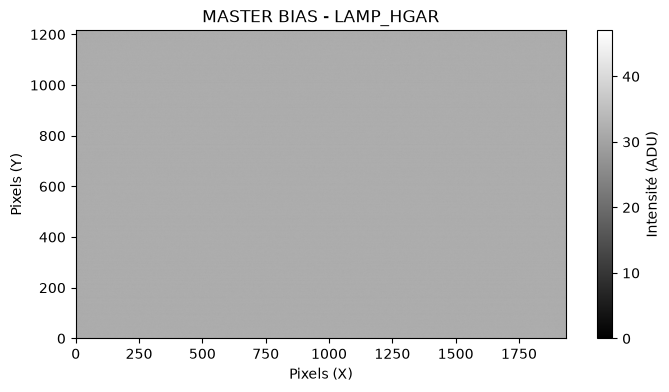

In [5]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_BIAS, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER BIAS - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

## **3. Creating the master dark**

We will also remove the master bias from each of them, as to obtain as thermically pure master dark

### Function

s important pour la suite (La soustraction sur tes "Lights")

Puisque ton `master_dark` est maintenant "pur" (sans le bruit de lecture), l'équation de prétraitement pour tes images d'objets (*Light frames*) change.

Au lieu de faire simplement `Light - Master_Dark`, tu devras faire :


$$\text{Image Corrigée} = \text{Light} - \text{Master Bias} - \text{Master Dark}$$

Cette méthode est la plus rigoureuse car elle te permettra plus tard (si tu le souhaites) de "scaler" ton dark. Par exemple, si tu as un Master Dark de 60s mais une image d'objet de 30s, tu pourras faire : `Light - Master_Bias - (Master_Dark * 0.5)`. C'est ultra pratique en astronomie professionnelle ou pour de la recherche d'exoplanètes où les temps de pose varient !

In [6]:
def master_dark(object_name,exp_time, master_bias):
    dark_folder = f"TRUE_DARK_{exp_time}_1/DARK_{exp_time}"
    dark_files = sorted(os.listdir(dark_folder))
    darks = np.zeros((MAX_H,MAX_W,len(dark_files)), dtype=np.float32)

    for i, dark in tqdm(enumerate(dark_files)): # loop for each bias in the bias folder
        with fits.open(f"{dark_folder}/{dark}") as hdul: # open fits file
            darks[:,:,i] = hdul[0].data.astype(np.float32) - master_bias.astype(np.float32)

    master_dark = np.median(darks, axis=2)
    return master_dark

In [7]:
MASTER_DARK = master_dark(OBJECT_NAME, EXPOSURE, MASTER_BIAS)

50it [00:01, 28.39it/s]


### Master dark visualization

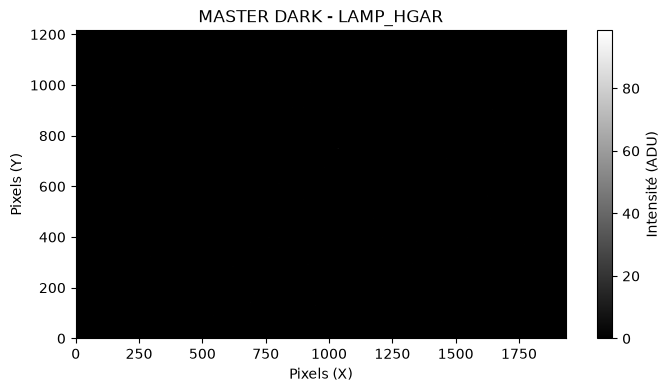

In [8]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_DARK, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER DARK - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

## **4. Creating the master flat**

Similarly to the master dark, we will substract the bias for each flat frame

### Function

In [9]:
def master_flat(object_name,exp_time, master_bias):
    flat_folder = f"TEST_FLAT/FLAT_{exp_time}"
    flat_files = sorted(os.listdir(flat_folder))
    flats = np.zeros((MAX_H,MAX_W,len(flat_files)), dtype=np.float32)

    for i, flat in tqdm(enumerate(flat_files)): # loop for each bias in the bias folder
        with fits.open(f"{flat_folder}/{flat}") as hdul: # open fits file
            flats[:,:,i] = hdul[0].data.astype(np.float32) - master_bias.astype(np.float32)

    raw_master_flat = np.median(flats, axis=2)

    master_flat = raw_master_flat / np.median(raw_master_flat) # correct for the vignetting/dust without changing the actual value of each pixel
    return master_flat

In [10]:
MASTER_FLAT = master_flat(OBJECT_NAME, EXPOSURE, MASTER_BIAS)

20it [00:00, 36.48it/s]


### Master flat visualization

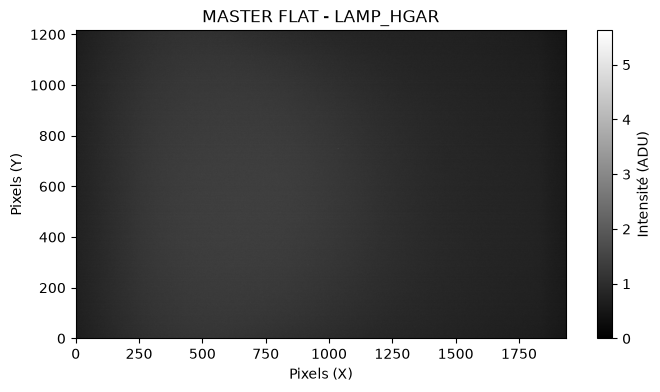

In [11]:
fig, ax = plt.subplots(figsize=(8,4))

im = ax.imshow(MASTER_FLAT, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER FLAT - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

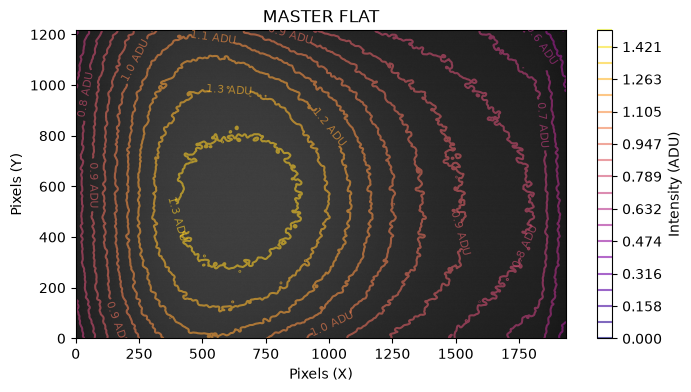

In [12]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

fig, ax = plt.subplots(figsize=(8,4))

# Astuce essentielle : on lisse légèrement l'image (sigma=3 ou 5) 
# UNIQUEMENT pour le calcul des contours, pour éviter le bruit pixel par pixel.
MASTER_FLAT_SMOOTHED = gaussian_filter(MASTER_FLAT, sigma=5)

# On définit des niveaux précis adaptés à ta dynamique (0 à 5 ADU)
# niveaux = [1.0, 2.0, 3.0, 4.0, 5.0]
niveaux = np.linspace(0, 1.5, 20)
im = ax.imshow(MASTER_FLAT, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# Tracé des contours
# cs = ax.contour(MASTER_FLAT_SMOOTHED, levels=niveaux, cmap='plasma', origin='lower',alpha=0.6)
cs = ax.contour(MASTER_FLAT_SMOOTHED, levels=niveaux, cmap='plasma', origin='lower',alpha=0.6)

# Ajout des étiquettes sur les lignes
ax.clabel(cs, inline=True, fontsize=8, fmt='%1.1f ADU')

ax.set_title(f"MASTER FLAT")# - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

fig.colorbar(cs, ax=ax, label="Intensity (ADU)")

plt.show()

## **5. Creating the final corrected image**

### Function

In [13]:
def master_science(object_name, exp_time, m_bias, m_dark, m_flat):
    science_folder = f"{object_name}/SCIENCE_{exp_time}"
    science_files = sorted(os.listdir(science_folder))
    sciences = np.zeros((MAX_H,MAX_W,len(science_files)), dtype=np.float32)

    for i, science in tqdm(enumerate(science_files)): # loop for each bias in the bias folder
        with fits.open(f"{science_folder}/{science}") as hdul: # open fits file
            sciences[:,:,i] = hdul[0].data.astype(np.float32) - m_bias.astype(np.float32) - m_dark.astype(np.float32)
            header = hdul[0].header

    master_science_uncorrected = np.median(sciences, axis=2)
    master_science = (np.median(sciences, axis=2)) / m_flat

    return master_science,master_science_uncorrected, header

In [14]:
MASTER_SCIENCE, MASTER_SCIENCE_UNCORR, header = master_science(OBJECT_NAME, EXPOSURE, MASTER_BIAS, MASTER_DARK, MASTER_FLAT)

50it [00:01, 25.40it/s]


### Master science visualisation

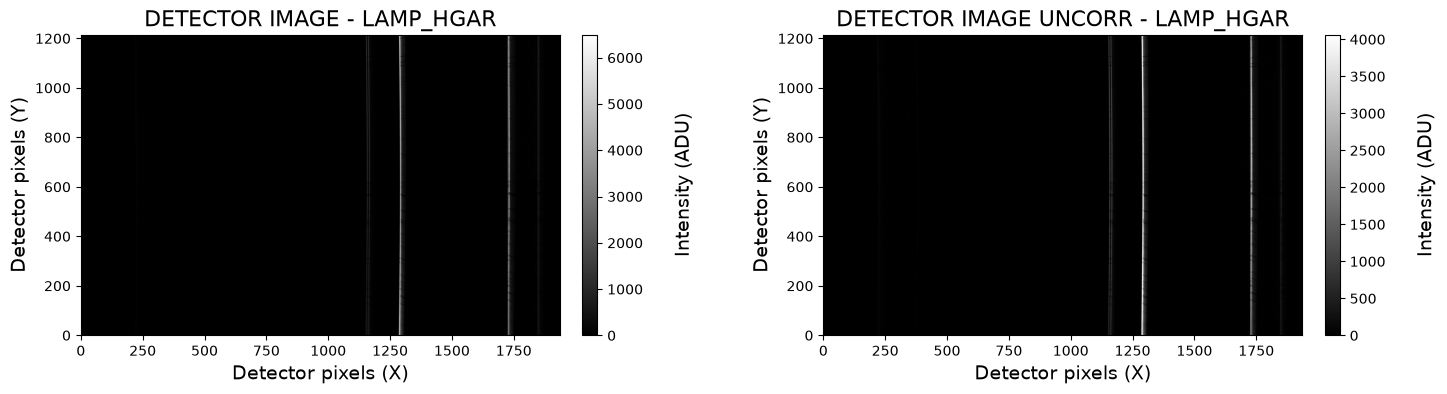

In [15]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,4))

im1 = ax1.imshow((MASTER_SCIENCE), cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# ax.set_title(f"Detector image - Mercury-Neon arc lamp spectra", fontsize=16)
ax1.set_title(f"DETECTOR IMAGE - {OBJECT_NAME}", fontsize=16)
ax1.set_xlabel("Detector pixels (X)", fontsize=14)
ax1.set_ylabel("Detector pixels (Y)", fontsize=14)

cbar1 = fig.colorbar(im1, ax=ax1, label="\nIntensity (ADU)",fraction=0.046, pad=0.04)
cbar1.set_label('\nIntensity (ADU)', fontsize=14)

im2 = ax2.imshow((MASTER_SCIENCE_UNCORR), cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# ax.set_title(f"Detector image - Mercury-Neon arc lamp spectra", fontsize=16)
ax2.set_title(f"DETECTOR IMAGE UNCORR - {OBJECT_NAME}", fontsize=16)
ax2.set_xlabel("Detector pixels (X)", fontsize=14)
ax2.set_ylabel("Detector pixels (Y)", fontsize=14)

cbar2 = fig.colorbar(im2, ax=ax2, label="\nIntensity (ADU)",fraction=0.046, pad=0.04)
cbar2.set_label('\nIntensity (ADU)', fontsize=14)

plt.tight_layout()
plt.show()

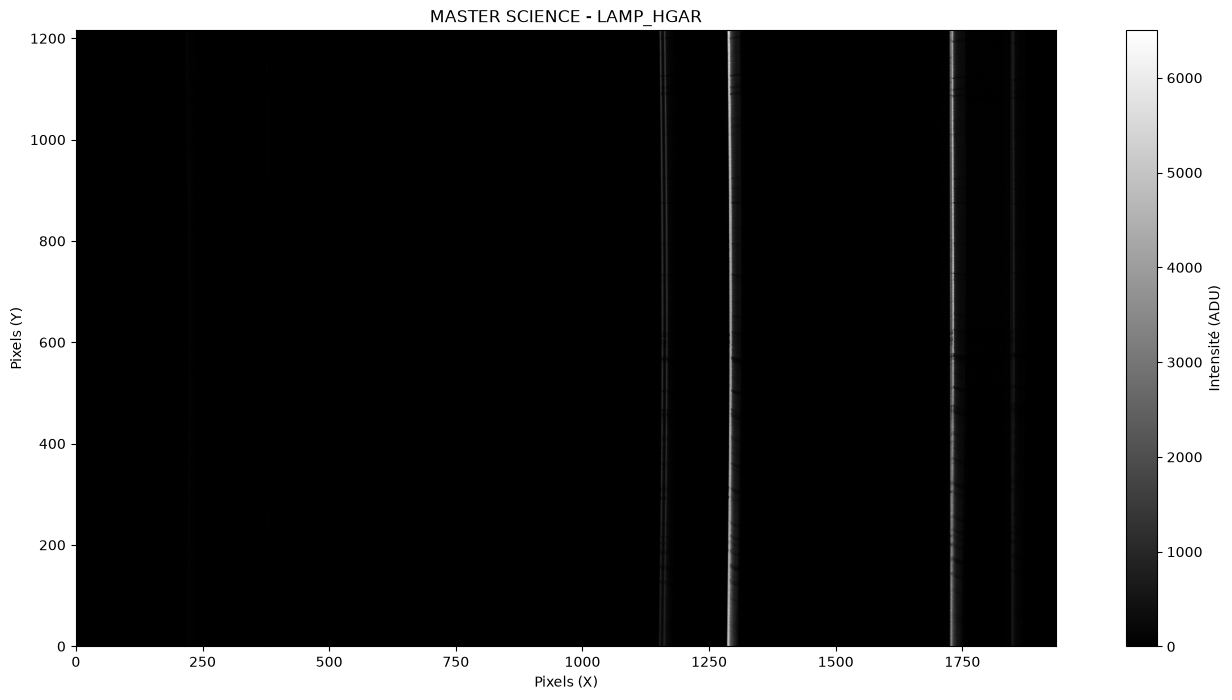

In [16]:
fig, ax = plt.subplots(figsize=(18,8))

im = ax.imshow(MASTER_SCIENCE, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER SCIENCE - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

### <span style="color:red">TODO : Think if I should create a FITS file for the final science calibrated image</span>.

## **6. Spectra extraction**

### Function

> **The spectra array needs to be reverse, as the +1 order on the detector is red on left and blue on right**

In [17]:
def spectra_plot(m_science, header, log=False, ylines=[0,607,1215],xmin=0,xmax=1936):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

    # m_science = header
    for line in ylines:
        if log:
            ax1.plot(np.log10(m_science[line,:][::-1] + 1 + np.abs(np.min(m_science[line,:][::-1]))),marker='.',ls='',label=f'Line : {line}') # reverse
            ax2.axhline(y=line, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={line}')
            # ax1.set_ylim(ymin=1.5)
        else:
            ax1.plot(m_science[line,:][::-1],marker='.',ls='',label=f'Line : {line}')
            ax2.axhline(y=line, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={line}')
            # ax1.set_ylim(ymin=1.5)

    # ax1.set_title(f"FITS - {header['DATE-OBS']}\n EXP : {header['EXPTIME']} - GAIN : {header['GAIN']}\n OBJ : {header['OBJECT']}- RA : {header['RA']} - DEC : {header['DEC']}")
    ax1.set_xlabel("Pixels (X)")
    ax1.set_ylabel("Intensity (ADU)")
    ax1.legend()
    

    ax1.grid(ls='--',c='lightgrey')
    ax1.set_axisbelow(True)
    ax1.set_xlim(xmin,xmax)



    im = ax2.imshow(m_science, cmap='gray', origin='lower', vmin=0)#, vmax=2000)
    
    # On trace la ligne rouge horizontale là où la coupe est faite
    
    ax2.set_title("Detector image (2D)")
    ax2.set_xlabel("Pixels (X)")
    ax2.set_ylabel("Pixels (Y)")
    ax2.legend(loc='upper right')

    fig.colorbar(im, ax=ax2, label="Intensité (ADU)", fraction=0.046, pad=0.04)

    fig.suptitle(f"FITS - {header['DATE-OBS']} | OBJ : {header['OBJECT']}\n"
                 f"EXP : {header['EXPTIME']} µs | GAIN : {header['GAIN']} dB | IMGMODE : {header['IMGMODE']}\nRA/DEC : {header['RA']}/{header['DEC']}", 
                 fontsize=12, y=0.98)

    plt.tight_layout() # Aligne proprement les graphiques sans qu'ils se chevauchent
    plt.show()

In [18]:
# spectra_plot(MASTER_SCIENCE, header, False, [0,600,1200],1700,1720)

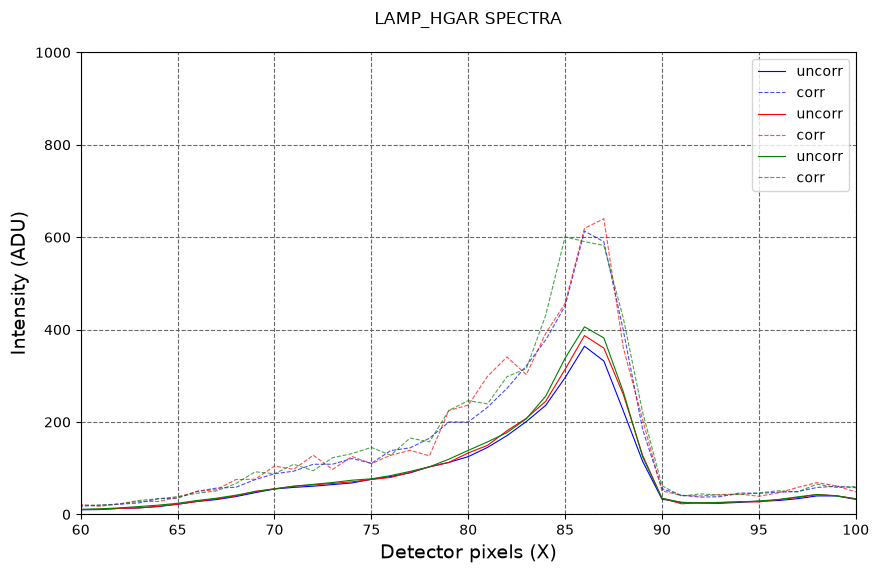

In [19]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
colors = ['blue', 'red', 'green']
lines = [0,600,1200]
for i, l in enumerate(lines):
    data = MASTER_SCIENCE_UNCORR[i,:][::-1]
    x, y = np.arange(1936), data

    data_corr = MASTER_SCIENCE[i,:][::-1]
    x, y_corr = np.arange(1936), data_corr

    peaks, _ = find_peaks(y, height=10, distance=3, prominence=(10,10000))#,threshold=100)

   
    # mask=[0,2,3,4,5,7,8,9]
    # ax.plot(x,y,c='black',lw=0.8)#,marker='.')
    # ax.plot(x,np.log10(y),c='black',lw=0.8)#,marker='.')
    ax.plot(x,(y),c=colors[i],lw=0.8,label='uncorr')#,marker='.')
    ax.plot(x,(y_corr),c=colors[i],lw=0.8,label='corr', ls='--',alpha=0.7)#,marker='.')

# ax.plot(peaks, np.log10(y[peaks]), "x")
# ax.plot(peaks[mask], y[peaks][mask], "x")
# ax.plot(x, np.log1p(MASTER_SCIENCE_UNCORR[600,:][::-1]),alpha=0.6)
# ax.axvline(x=771,ls='--',alpha=0.7)
# ax.axvline(x=780,ls='--',alpha=0.7)
ax.grid(ls='--',c='dimgrey')
ax.set_xlabel('Detector pixels (X)',fontsize=14)
ax.set_ylabel('Intensity (ADU)',fontsize=14)
ax.set_title(f'{OBJECT_NAME} SPECTRA\n')
# ax.set_title(f'Mercury-Neon arc lamp spectra', fontsize=16)
# ax.set_xlim(760,790)
ax.set_xlim(60,100)
# ax.set_xlim(620,670)
ax.set_ylim(0,1000)
ax.legend()
plt.show()


In [20]:
# np.set_printoptions(threshold=np.inf)
# print(y)

In [21]:
# from scipy.signal import find_peaks_cwt

# fig, ax = plt.subplots(figsize=(9,6))

# widths = np.arange(1,20)

# y_test = MASTER_SCIENCE[500,:][::-1]
# # a = find_peaks_cwt(MASTER_SCIENCE[300,:][::-1],widths,min_snr=3, noise_perc=5,gap_thresh=2)
# peaks, props = find_peaks(y_test, prominence=10, distance=5)
# ax.grid(ls='--',c='dimgrey')
# ax.plot(x,(np.log10(y_test)))
# # ax.plot(peaks,(y[peaks]), "x")
# ax.set_title(f"Finding peak of {OBJECT_NAME} w/ 'find_peaks_cwt'")
# ax.set_ylabel('Intensity (ADU)')
# ax.set_xlabel('Detector pixels (X)')

{365.02: None,
366.33: None,


404.66: None,
435.84: None,
546.07: None,
576.96: None,
579.07: None,

724.52: None}

## **7.Identifying peaks**

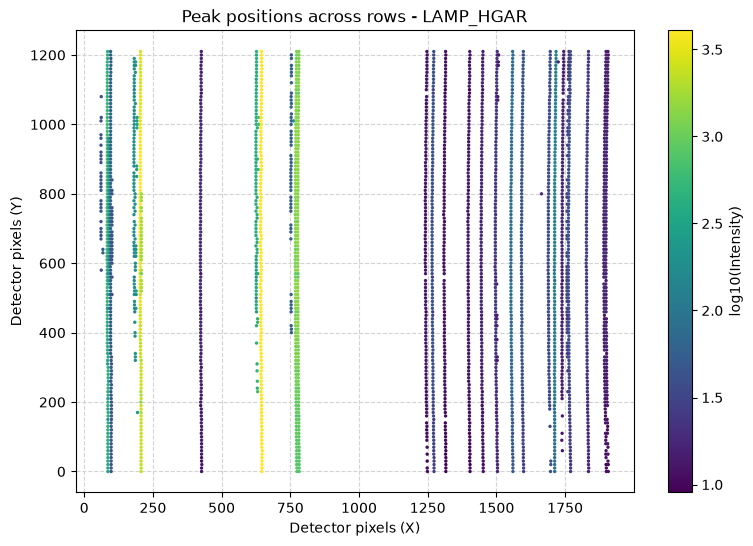

In [22]:
from scipy.signal import find_peaks
import numpy as np

n_rows = MAX_H # nombre de rangées horizontales
rows = np.arange(0, n_rows, 10)  # échantillonne toutes les 10 lignes, ajuste selon besoin

all_peaks = []   # liste de (row_index, x_pixel, intensity)
for row in rows:
    y_row = MASTER_SCIENCE_UNCORR[row, :][::-1] # on remet le spectre avec bleu a gauche et rouge a droite (augmentation longueur d'onde de gauche a droite)
    peaks, props = find_peaks(y_row, prominence=5, distance=5)
    for p in peaks:
        all_peaks.append((row, p, y_row[p]))

all_peaks = np.array(all_peaks)  # colonnes: [row, x_pixel, intensity]

fig, ax = plt.subplots(figsize=(9,6))
sc = ax.scatter(all_peaks[:,1], all_peaks[:,0], c=np.log10(all_peaks[:,2]), 
                 cmap='viridis', s=8,marker='.')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector pixels (Y)')
ax.set_title(f"Peak positions across rows - {OBJECT_NAME}")
ax.grid(ls='--',c='lightgrey')
ax.set_axisbelow(True)
# ax.set_xlim(1650,1750)
plt.colorbar(sc, label='log10(Intensity)')

In [23]:
# from collections import defaultdict

# tracks = defaultdict(list)  # track_id -> liste de (row, x, intensity)
# next_id = 0
# last_row_peaks = {}  # x_pixel -> track_id, pour la dernière ligne traitée

# tol = 5  # tolérance en pixels pour associer un pic à une raie existante

# for row in rows:
#     # y_row = MASTER_SCIENCE_UNCORR[row, :][::-1]
#     y_row = MASTER_SCIENCE_UNCORR[row, :][::-1]
#     peaks, _ = find_peaks(y_row, prominence=5, distance=5)
#     current_row_peaks = {}
#     for p in peaks:
#         # cherche la raie la plus proche dans la ligne précédente
#         matched_id = None
#         for x_prev, tid in last_row_peaks.items():
#             if abs(p - x_prev) < tol:
#                 matched_id = tid
#                 break
#         if matched_id is None:
#             matched_id = next_id
#             next_id += 1
#         tracks[matched_id].append((row, p, y_row[p]))
#         current_row_peaks[p] = matched_id
#     last_row_peaks = current_row_peaks

# # Plot chaque track avec une couleur différente
# fig, ax = plt.subplots(figsize=(9,6))
# for tid, pts in tracks.items():
#     if len(pts) > 50:  
#         pts = np.array(pts)
#         # print(pts)
#         # ax.plot(pts[:,1], pts[:,0], '.-', ms=3, label=f'raie {tid}')
#         sc = ax.scatter(pts[:,1], pts[:,0], c=np.log10(pts[:,2]), 
#                  cmap='viridis', s=8,marker='.')
# ax.set_xlabel('Detector pixels (X)')
# ax.set_ylabel('Detector row (Y)')
# ax.set_title(f"Line identification - {OBJECT_NAME}")
# ax.grid(ls='--',c='lightgrey')
# ax.set_xlim(0,MAX_W)




In [24]:
# from collections import defaultdict
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import find_peaks

# tracks = defaultdict(list)
# next_id = 0
# last_row_peaks = {}
# tol = 5

# prop_width = []#np.zeros((len(rows),12))
# prop_prominence = []
# prop_peaks = []
# for i, row in enumerate(rows):
#     y_row = MASTER_SCIENCE_UNCORR[row, :][::-1]
#     peaks, prop = find_peaks(y_row, prominence=5, distance=5,width=2) # peak finding algorithm with scipy.signal
#     # prominence is how much verticaly distance the peak should be from the rest
#     # distance is the minimal distance between two peaks
#     # width is the minimal width of the peaks
#     prop_peaks.append(peaks)
#     prop_width.append(prop['widths'])
#     prop_prominence.append(prop['prominences'])
#     # for width in prop['widths'] :
#         # popt, pcov = curve_fit(gauss, xdata, ydata)
#     current_row_peaks = {}
#     for p in peaks:
#         matched_id = None
#         for x_prev, tid in last_row_peaks.items(): # comparaison with previous line
#             if abs(p - x_prev) < tol: # if the position difference between previous x position and current is below 5 pixels, we continue
#                 matched_id = tid
#                 break
#         if matched_id is None: # if not, we associate it to a new id (new line)
#             matched_id = next_id
#             next_id += 1
#         tracks[matched_id].append((row, p, y_row[p])) # we track the peak position and intensity in the dict
#         current_row_peaks[p] = matched_id
#     last_row_peaks = current_row_peaks # save to compare in next loop

#     # (row, centre_fit, FWHM, amplitude, succès_du_fit

In [25]:

# all_intensities = np.concatenate([
#     np.log10(np.array(pts)[:, 2]) for pts in tracks.values() if len(pts) > 50
# ])
# vmin, vmax = all_intensities.min(), all_intensities.max()

# fig, ax = plt.subplots(figsize=(9, 6))

# # sc = None 
# for tid, pts in tracks.items():
#     if len(pts) > 50:
#         pts = np.array(pts)
#         sc = ax.scatter(
#             pts[:, 1], pts[:, 0],
#             c=np.log10(pts[:, 2]),
#             cmap='viridis',
#             vmin=vmin, vmax=vmax,
#             s=8, marker='.'
#         )

# # if sc is not None:
# cbar = fig.colorbar(sc, ax=ax)
# cbar.set_label('log10(intensité)')

# ax.set_xlabel('Detector pixels (X)')
# ax.set_ylabel('Detector row (Y)')
# ax.set_title(f"Line identification - {OBJECT_NAME}")
# ax.grid(ls='--', c='lightgrey')
# ax.set_xlim(0, MAX_W)
# # ax.set_xlim(765,790)
# plt.show()

to retrieve each line correctly, it should only keep the on with the same intensity give or take

## **8. Fitting the parabolas**

In [26]:
# import numpy as np

# fits = {}  # track_id -> (coeffs, rows_used, x_used)

# for tid, pts in tracks.items():
#     if len(pts) < 40:  # ignore les tracks trop courtes / pas assez de points
#         continue
#     pts = np.array(pts)
#     rows_t = pts[:, 0]
#     # print(rows_t)
#     x_t = pts[:, 1]
#     insty = pts[:,2]
    
#     coeffs, res, _, _, _ = np.polyfit(rows_t, x_t, deg=2, full=True)  # [a, b, c] pour a*row^2 + b*row + c
#     fits[tid] = (coeffs, rows_t, x_t,insty)

In [27]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns


# def plot_track_and_residuals(fits_dict, track_id):
#     # 1. Vérifier si l'identifiant existe
#     if track_id not in fits_dict:
#         print(f"Le track_id {track_id} n'est pas dans le dictionnaire 'fits'.")
#         return

#     # Extraire les données stockées
#     coeffs, rows_t, x_t, insty = fits_dict[track_id]

#     x_fit = np.polyval(coeffs, rows_t)
#     residuals = x_t - x_fit

#     sns.set_theme(style="whitegrid")
#     fig, (ax_main, ax_res) = plt.subplots(
#         2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
#     )

#     sns.scatterplot(
#         x=rows_t,
#         y=x_t,
#         # hue=insty,
#         palette="viridis",
#         ax=ax_main,
#         alpha=0.8,
#         edgecolor=None,
#     )
#     # Afficher la ligne du fit parabolique
#     sns.lineplot(
#         x=rows_t,
#         y=x_fit,
#         color="red",
#         linewidth=2.5,
#         ax=ax_main,
#         label=f"Fit Deg 2 (ID: {track_id})",
#     )

#     ax_main.set_ylabel("Position X")
#     ax_main.set_title(
#         f"Ajustement Parabolique et Résidus pour la Trace n°{track_id}",
#         fontsize=14,
#     )
#     ax_main.legend()

#     # --- GRAPHIC DES RÉSIDUS ---
#     # Tracer les résidus
#     sns.scatterplot(
#         x=rows_t,
#         y=residuals,
#         color="purple",
#         alpha=0.6,
#         ax=ax_res,
#         edgecolor=None,
#     )
#     # Ligne horizontale à 0 (le fit parfait)
#     ax_res.axhline(y=0, color="black", linestyle="--", linewidth=1.5)

#     ax_res.set_xlabel("Lignes (Rows)")
#     ax_res.set_ylabel("Résidus (Data - Fit)")

#     plt.tight_layout()
#     plt.show()

In [28]:


# # --- COMMENT L'UTILISER ? ---
# # Étape 1 : Choisis un ID au hasard ou le premier disponible
# available_ids = list(fits.keys())
# print(f'Available ids = {available_ids}')
# if available_ids:
#     target_id = available_ids[5]  # On prend la première parabole par exemple
#     plot_track_and_residuals(fits, target_id)
# # else:
# #     print("Aucune trace n'a plus de 40 points dans vos données.")

In [29]:
# fig, ax = plt.subplots(figsize=(9,6))
# import matplotlib.ticker as ticker

# for tid, (coeffs, rows_t, x_t, insty) in fits.items():
#     # sc = ax.scatter(x_t, rows_t, c=np.log10(insty), s=12, cmap='viridis', alpha=0.5)
#     sc = ax.plot(x_t, rows_t,'.', ms=4, alpha=0.4)
#     row_fine = np.linspace(0, MAX_H, MAX_H+1)
#     x_fit = np.polyval(coeffs, row_fine)
#     ax.plot(x_fit, row_fine, '-', lw=1.5, label=f'raie {tid}')

# ax.grid(ls='--',c='lightgrey',which='both')
# ax.set_xlabel('Detector pixels (X)')
# ax.set_ylabel('Detector row (Y)')
# ax.set_title(f"Parabolic fitting - {OBJECT_NAME}")
# ax.set_xlim(765,790)
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
# # ax.legend(fontsize=7)
# plt.show()
# # cbar = fig.colorbar(sc, ax=ax, label='log10(Intensity)')


---

## **7.b Gaussian finding peaks algorithm**

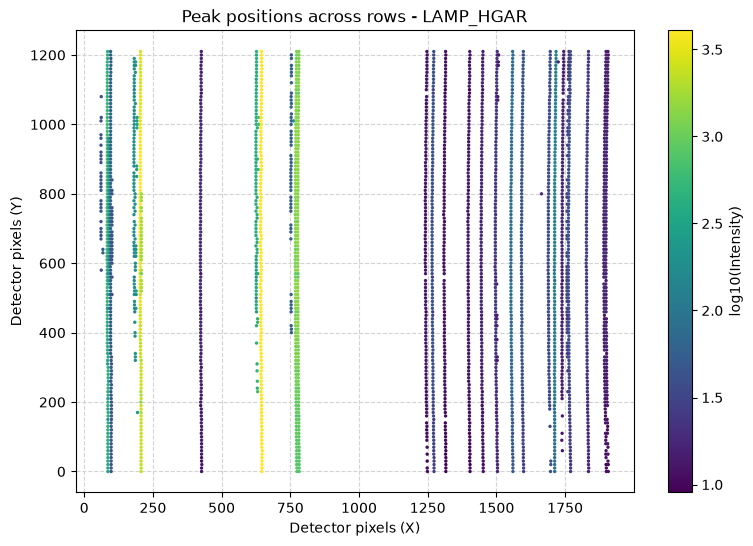

In [30]:
from scipy.signal import find_peaks
import numpy as np

n_rows = MAX_H # nombre de rangées horizontales
rows = np.arange(0, n_rows, 10)  # échantillonne toutes les 10 lignes, ajuste selon besoin

all_peaks = []   # liste de (row_index, x_pixel, intensity)
for row in rows:
    y_row = MASTER_SCIENCE_UNCORR[row, :][::-1] # on remet le spectre avec bleu a gauche et rouge a droite (augmentation longueur d'onde de gauche a droite)
    peaks, props = find_peaks(y_row, prominence=5, distance=5)
    for p in peaks:
        all_peaks.append((row, p, y_row[p]))

all_peaks = np.array(all_peaks)  # colonnes: [row, x_pixel, intensity]

fig, ax = plt.subplots(figsize=(9,6))
sc = ax.scatter(all_peaks[:,1], all_peaks[:,0], c=np.log10(all_peaks[:,2]), 
                 cmap='viridis', s=8,marker='.')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector pixels (Y)')
ax.set_title(f"Peak positions across rows - {OBJECT_NAME}")
ax.grid(ls='--',c='lightgrey')
ax.set_axisbelow(True)
# ax.set_xlim(1650,1750)
plt.colorbar(sc, label='log10(Intensity)')

In [31]:
def gauss(x, H, A, x0, sigma):
    return H + A * np.exp(-(x - x0)**2 / (2 * sigma**2))
    # H : plafond de bruit
    # A : intensity
    # x0 : mean position
    # sigma : standard deviation

In [32]:
from scipy.special import erf
def asymGaussian(x, A, x0, sigma, alpha, H):
    """Gaussienne asymétrique pour curve_fit.

    Arguments:
    - x: données de l'axe X (pixels)
    - A: Facteur d'amplitude (proportionnel à l'aire sous la courbe)
    - x0: Position centrale sous-jacente
    - sigma: Largeur de la fonction
    - alpha: Facteur d'asymétrie (alpha=0 donne une gaussienne normale,
             alpha > 0 incline vers la droite, alpha < 0 vers la gauche)
    - H: Ligne de base (background)
    """
    amp = A / (sigma * np.sqrt(2 * np.pi))
    spread = np.exp(-((x - x0) ** 2.0) / (2.0 * sigma**2.0))
    skew = 1.0 + erf((alpha * (x - x0)) / (sigma * np.sqrt(2.0)))

    return amp * spread * skew + H

In [33]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

tracks = defaultdict(list)
next_id = 0
last_row_peaks = {}
tol = 2

prop_pos = []
prop_noise = []#np.zeros((len(rows),12))
prop_prominence = []
prop_peaks = []
prop_sig = []
prop_alpha = []
x_complet = np.arange((MAX_W))
  
for i, row in (enumerate(tqdm(rows))):
    y_row = MASTER_SCIENCE_UNCORR[row, :][::-1]
    peaks, prop = find_peaks(y_row, prominence=5, distance=5,width=2) # peak finding algorithm with scipy.signal
    # print(peaks)
    # prominence is how much verticaly distance the peak should be from the rest
    # distance is the minimal distance between two peaks
    # width is the minimal width of the peaks

    current_row_peaks = {}

    gaussian_peaks = np.zeros_like(peaks).astype(np.float32)
    gaussian_sig = np.zeros_like(peaks).astype(np.float32)
    gaussian_prominence = np.zeros_like(peaks).astype(np.float32)
    gaussian_noise = np.zeros_like(peaks).astype(np.float32)
    gaussian_alpha = np.zeros_like(peaks).astype(np.float32)

    # print(gaussian_peaks)
    i=0
    for p, wi in zip(peaks,prop['widths']):
        p = int(p)
        # w = 3#int(0.8*w)
        w = max(int(1.2 * wi), 3)
        window_mask = (x_complet >= (p - w)) & (x_complet <= (p + w))
        x_fit = x_complet[window_mask]
        y_fit = y_row[window_mask]
        # print(x_fit)

        est_H = np.min(y_fit)
        est_A = (np.max(y_fit) - est_H) * (
            w * 10
        )  # L'aire est proportionnelle à la hauteur * largeur
        est_x0 = p  # La position de ton pic (find_peaks)
        est_sigma = max(w / 2.355, 0.5) # Astuce physique : sigma est lié à la FWHM (largeur à mi-hauteur) par ce facteur
        est_alpha = -5  

        # p0 = [est_H, est_A, est_x0, est_sigma]
        p0 = [est_A, est_x0, est_sigma, est_alpha, est_H]
        lower_bounds = [0, p - 0.5*w, 0.05, -7.0, 0]
        upper_bounds = [np.inf, p + 0.5*w, 1.1*w, 0.1, np.inf]
        popt, pcov = curve_fit(
        asymGaussian,
        x_fit,
        y_fit,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=10000,
    )

    # On récupère les paramètres fittés
        A_fit, x0_fit, sigma_fit, alpha_fit, H_fit = popt

        # ATTENTION : Avec l'asymétrie, le maximum réel du pic n'est plus exactement en x0_fit !
        # Pour ton tracking de raies, x0_fit reste une excellente coordonnée stable.
        # gaussian_peaks.append(x0_fit
        # H_fit, A_fit, x0_fit, sigma_fit = popt
        # print(x0_fit)
        gaussian_peaks[i] = x0_fit
        gaussian_sig[i] = sigma_fit
        gaussian_prominence[i] = A_fit
        gaussian_noise[i] = H_fit
        gaussian_alpha[i] = alpha_fit
        i+=1
    prop_pos.append(gaussian_peaks)
    prop_sig.append(gaussian_sig)
    prop_prominence.append(gaussian_prominence)
    prop_noise.append(gaussian_noise)
    prop_alpha.append(gaussian_alpha)
    # print(gaussian_peaks)

    # print(gaussian_peaks)
    for p_entier, p, sig, prom, noise, alpha in zip(peaks, gaussian_peaks,gaussian_sig,gaussian_prominence,gaussian_noise,gaussian_alpha):
        matched_id = None
        for x_prev, tid in last_row_peaks.items(): # comparaison with previous line
            if abs(p_entier - x_prev) < tol: # if the position difference between previous x position and current is below 5 pixels, we continue
                matched_id = tid
                break
        if matched_id is None: # if not, we associate it to a new id (new line)
            matched_id = next_id
            next_id += 1
        tracks[matched_id].append((row, p, prom, sig, noise, alpha)) # we track the peak position and intensity in the dict
        current_row_peaks[p_entier] = matched_id
    last_row_peaks = current_row_peaks # save to compare in next loop

    # (row, centre_fit, FWHM, amplitude, succès_du_fit

100%|██████████| 122/122 [00:16<00:00,  7.57it/s]


In [34]:
# from collections import defaultdict
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import find_peaks

# tracks = defaultdict(list)
# next_id = 0
# last_row_peaks = {}
# tol = 5

# prop_pos = []
# prop_noise = []#np.zeros((len(rows),12))
# prop_prominence = []
# prop_peaks = []
# prop_sig = []
# x_complet = np.arange((MAX_W))
  
# for i, row in enumerate(rows):
#     y_row = MASTER_SCIENCE_UNCORR[row, :][::-1]
#     peaks, prop = find_peaks(y_row, prominence=5, distance=5,width=2) # peak finding algorithm with scipy.signal
#     # print(peaks)
#     # prominence is how much verticaly distance the peak should be from the rest
#     # distance is the minimal distance between two peaks
#     # width is the minimal width of the peaks


#     # prop_peaks.append(peaks)
#     # prop_width.append(prop['widths'])
#     # prop_prominence.append(prop['prominences'])
#     # for width in prop['widths'] :
#         # popt, pcov = curve_fit(gauss, xdata, ydata)
#     current_row_peaks = {}
#     gaussian_peaks = np.zeros_like(peaks).astype(np.float32)
#     gaussian_sig = np.zeros_like(peaks).astype(np.float32)
#     gaussian_prominence = np.zeros_like(peaks).astype(np.float32)
#     gaussian_noise = np.zeros_like(peaks).astype(np.float32)

#     # print(gaussian_peaks)
#     i=0
#     for p, w in zip(peaks,prop['widths']):
#         p = int(p)
#         w = 5#int(2*w)
#         window_mask = (x_complet >= (p - w)) & (x_complet <= (p + w))
#         x_fit = x_complet[window_mask]
#         y_fit = y_row[window_mask]
#         # print(x_fit)

#         est_H = np.min(y_fit)
#         est_A = np.max(y_fit) - est_H
#         est_x0 = p  # La position brute trouvée par find_peaks
#         est_sigma = (
#             w / 2.355
#         )  # Astuce physique : sigma est lié à la FWHM (largeur à mi-hauteur) par ce facteur

#         p0 = [est_H, est_A, est_x0, est_sigma]
#         popt, pcov = curve_fit(gauss, x_fit,y_fit, p0)
#         H_fit, A_fit, x0_fit, sigma_fit = popt
#         # print(x0_fit)
#         gaussian_peaks[i] = x0_fit
#         gaussian_sig[i] = sigma_fit
#         gaussian_prominence[i] = A_fit
#         gaussian_noise[i] = H_fit
#         i+=1
#     prop_pos.append(gaussian_peaks)
#     prop_sig.append(gaussian_sig)
#     prop_prominence.append(gaussian_prominence)
#     prop_noise.append(gaussian_noise)
#     # print(gaussian_peaks)

#     # print(gaussian_peaks)
#     for p_entier, p, sig, prom, noise in zip(peaks, gaussian_peaks,gaussian_sig,gaussian_prominence,gaussian_noise):
#         matched_id = None
#         for x_prev, tid in last_row_peaks.items(): # comparaison with previous line
#             if abs(p_entier - x_prev) < tol: # if the position difference between previous x position and current is below 5 pixels, we continue
#                 matched_id = tid
#                 break
#         if matched_id is None: # if not, we associate it to a new id (new line)
#             matched_id = next_id
#             next_id += 1
#         tracks[matched_id].append((row, p, prom, sig, noise)) # we track the peak position and intensity in the dict
#         current_row_peaks[p_entier] = matched_id
#     last_row_peaks = current_row_peaks # save to compare in next loop

#     # (row, centre_fit, FWHM, amplitude, succès_du_fit

In [35]:
# tracks[1]

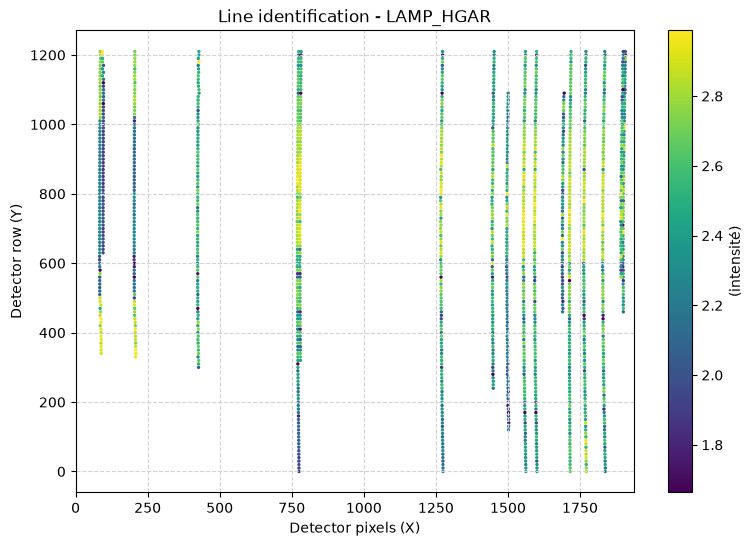

In [36]:

all_intensities = np.concatenate([
    np.log10(np.array(pts)[:, 2]) for pts in tracks.values() if len(pts) > 40
])
# vmin, vmax = all_intensities.min(), all_intensities.max()

fig, ax = plt.subplots(figsize=(9, 6))

# sc = None 
for tid, pts in tracks.items():
    if len(pts) > 50:
        pts = np.array(pts)
        sc = ax.scatter(
            pts[:, 1], pts[:, 0],
            c=np.log10(pts[:, 2]),
            cmap='viridis',
            # vmin=vmin, vmax=vmax,
            s=8, marker='.'
        )

# if sc is not None:
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('(intensité)')

ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Line identification - {OBJECT_NAME}")
ax.grid(ls='--', c='lightgrey')
ax.set_xlim(0, MAX_W)
# ax.set_xlim(765,790)
plt.show()

<>:50: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:50: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_32898/1166745124.py:50: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  cbar.set_label("$\log_{10}(\\text{Intensité})$", fontsize=11)


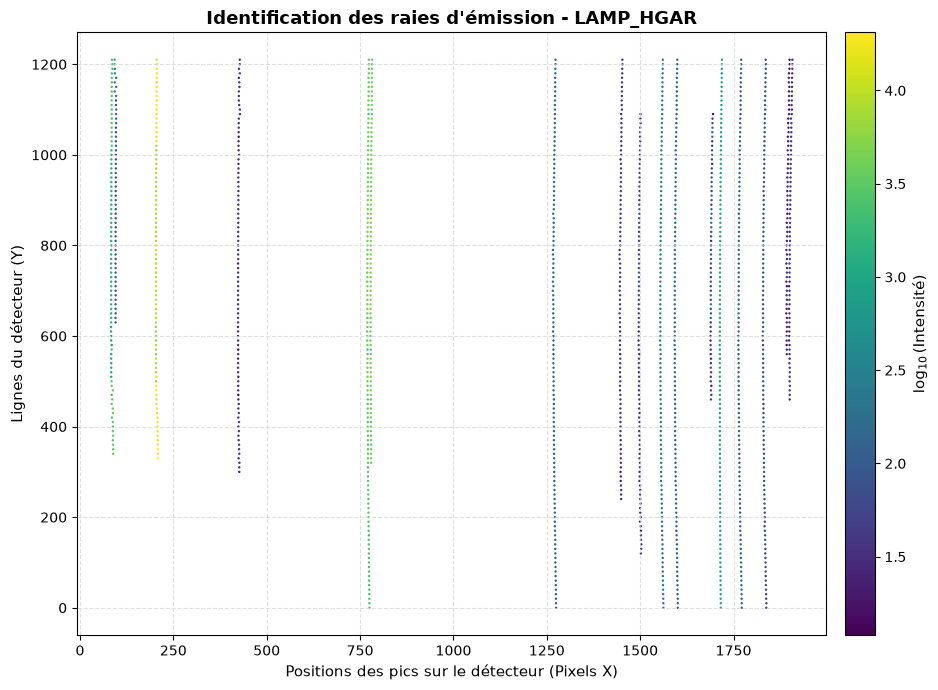

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculer vmin et vmax de manière sécurisée (on ignore le bruit <= 0 pour le log)
valid_intensities = []
for pts in tracks.values():
    if len(pts) > 50:
        intensities = np.array(pts)[:, 2]
        # On ne garde que les intensités strictement positives pour le log10
        valid_intensities.extend(intensities[intensities > 0])

all_log_intensities = np.log10(valid_intensities)
vmin, vmax = all_log_intensities.min(), all_log_intensities.max()

# 2. Initialiser la figure
fig, ax = plt.subplots(figsize=(10, 7))

# On initialise sc à None pour éviter les plantages si la boucle est vide
sc = None

# 3. Tracer chaque trajectoire
for tid, pts in tracks.items():
    if len(pts) > 50:
        pts = np.array(pts)

        x_coords = pts[:, 1]  # Position du pic fitté
        y_coords = pts[:, 0]  # Numéro de ligne du détecteur
        intensities = pts[:, 2]
        # err = pts[:, 3]

        # Remplacer les intensités aberrantes (<= 0) par un tout petit nombre pour éviter le crash du log
        intensities_clipped = np.clip(intensities, 1e-10, None)
        log_c = np.log10(intensities_clipped)

        sc = ax.scatter(
            x_coords,
            y_coords,
            c=log_c,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            s=12,  # Légèrement plus grand pour une meilleure visibilité
            marker=".",
            edgecolor="none",  # Supprime la bordure des points pour un rendu plus net
        )

# 4. Ajouter la colorbar SEULEMENT si des données ont été tracées
if sc is not None:
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("$\log_{10}(\\text{Intensité})$", fontsize=11)
else:
    print("Attention: Aucune trace n'avait plus de 50 points à afficher.")

# 5. Habillage du graphique (Style Astrophysique)
ax.set_xlabel("Positions des pics sur le détecteur (Pixels X)", fontsize=11)
ax.set_ylabel("Lignes du détecteur (Y)", fontsize=11)
ax.set_title(
    f"Identification des raies d'émission - {OBJECT_NAME}",
    fontsize=13,
    weight="bold",
)

ax.grid(True, linestyle="--", color="lightgrey", alpha=0.7)
# ax.set_xlim(0, MAX_W)
# ax.set_xlim(0, 250)

# Inverser l'axe Y est souvent utile en imagerie scientifique pour que la ligne 0 soit en haut
# ax.invert_yaxis()

plt.tight_layout()
plt.show()

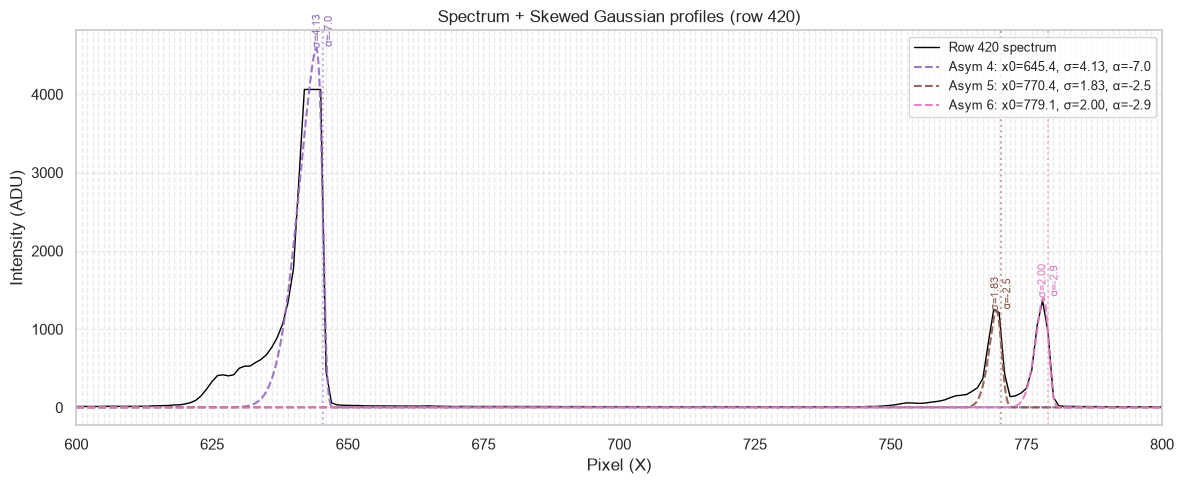

In [115]:
selected_row = 420
idx = np.argmin(np.abs(rows - selected_row)) if "rows" in globals() else 0

y = MASTER_SCIENCE_UNCORR[selected_row, :][::-1]
x = np.arange(MAX_W)

# --- RECOUVREMENT DES PARAMÈTRES ---
# /!\ Attention : Assure-toi que tes listes globales contiennent bien les sorties du fit asymétrique !
# Si prop_prominence contient "A_fit" et prop_noise contient "H_fit", etc.
centers = prop_pos[idx] if (len(prop_pos) > idx) else np.array([])
sigmas = prop_sig[idx] if (len(prop_sig) > idx) else np.array([])

# Supposons ici que tu as sauvé alpha et A (l'aire) dans des tableaux dédiés :
alphas = prop_alpha[idx] if ("prop_alpha" in globals() and len(prop_alpha) > idx) else np.zeros_like(centers)
A_values = prop_prominence[idx] if ("prop_A" in globals() and len(prop_prominence) > idx) else prop_prominence[idx]  
baselines = prop_noise[idx] if ("prop_noisee" in globals() and len(prop_noise) > idx) else np.full_like(centers, np.min(y))

plt.figure(figsize=(12, 5))
plt.plot(x, y, color="black", lw=1, label=f"Row {selected_row} spectrum")

# Fenêtre de zoom (pixels 1700 à 1900)
X_MIN, X_MAX = 600, 800
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, c in enumerate(centers):
    c = float(c)
    

    # Filtre de la fenêtre de zoom
    if c < X_MIN or c > X_MAX:
        continue

    # Récupération des paramètres du fit asymétrique pour ce pic
    sigma = float(sigmas[i]) if (i < len(sigmas)) else 2.0
    alpha_param = float(alphas[i]) if (i < len(alphas)) else 0.0
    A_param = float(A_values[i]) if (i < len(A_values)) else 100.0
    H_param = float(baselines[i]) if (i < len(baselines)) else np.min(y)

    if sigma <= 0 or not np.isfinite(sigma):
        continue

    # --- GENERATION DU PROFIL ASYMÉTRIQUE ---
    x_fine = np.linspace(X_MIN, X_MAX, (X_MAX - X_MIN) * 20)
    # On utilise la vraie formule mathématique fittée
    # y_gauss_asym = asymGaussian(x, A_param, c, sigma, alpha_param, H_param)
    y_gauss_asym_fine = asymGaussian(
    x_fine, A_param, c, sigma, alpha_param, H_param
    )
    
    # Trouver le maximum de la courbe pour placer correctement le texte d'annotation
    # (car avec l'asymétrie, le sommet n'est plus exactement en x0/c !)
    y_max_profile = np.max(y_gauss_asym_fine)

    # Plot du profil fitté
    plt.plot(
        x_fine,
        y_gauss_asym_fine,
        ls="--",
        color=colors[i % len(colors)],
        alpha=0.9,
        label=f"Asym {i}: x0={c:.1f}, σ={sigma:.2f}, α={alpha_param:.1f}",
    )

    # Ligne verticale sur le x0 (le centre mathématique)
    plt.axvline(c, color=colors[i % len(colors)], alpha=0.5, ls=":")

    # Annotation au-dessus du vrai sommet de la courbe
    plt.text(
        c,
        y_max_profile,
        f"σ={sigma:.2f}\nα={alpha_param:.1f}",
        color=colors[i % len(colors)],
        fontsize=8,
        ha="center",
        va="bottom",
        rotation=90,
    )
import matplotlib.ticker as ticker
plt.xlabel("Pixel (X)")
plt.ylabel("Intensity (ADU)")
plt.title(f"Spectrum + Skewed Gaussian profiles (row {selected_row})")
plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(1))

plt.legend(fontsize=9, loc="upper right")
plt.grid(ls="--", alpha=0.4,which='both')
plt.xlim(X_MIN, X_MAX)
plt.tight_layout()
plt.show()

In [39]:
import numpy as np

fits = {}  # track_id -> (coeffs, rows_clean, x_clean, insty_clean)

for tid, pts in tracks.items():
    if (
        len(pts) < 50
    ):  # Ignore les tracks trop courtes / pas assez de points
        continue

    pts = np.array(pts)
    rows_t = pts[:, 0]
    x_t = pts[:, 1]
    insty = pts[:, 2]

    # 1. Premier fit initial (vulnérable aux sauts de raie)
    coefs_init = np.polyfit(rows_t, x_t, deg=2)
    fit_init = np.polyval(coefs_init, rows_t)

    # 2. Calcul des résidus et filtrage (Sigma-Clipping)
    residus = x_t - fit_init
    seuil_pixels = 0.05  # Tolérance : max 0.3 pixel d'écart avec la parabole

    # On crée le masque pour isoler les points propres
    mask_clean = np.abs(residus) < seuil_pixels

    # Sécurité : si jamais le masque vire trop de points (ex: raie très bruitée),
    # on évite un crash de polyfit en gardant les données initiales.
    if np.sum(mask_clean) >= 10:
        rows_clean = rows_t[mask_clean]
        x_clean = x_t[mask_clean]
        insty_clean = insty[mask_clean]
    else:
        rows_clean = rows_t
        x_clean = x_t
        insty_clean = insty

    
    N = len(mask_clean)

    # 2. Nombre de paramètres du modèle (degré 2 -> 3 paramètres: a, b, c)
    m = 3
    dof = N - m    

    # 3. Fit final ultra-propre sur les données filtrées !
    # coefs_finals = np.polyfit(rows_clean, x_clean, deg=2,full=True)
    res = np.polyfit(rows_clean, x_clean, deg=2, full=True)

    # 2. On déballe proprement les variables
    coeffs = res[0]
    ssr_array = res[1]  # C'est une liste contenant la somme des carrés des résidus

    # Sécurité : polyfit renvoie une liste vide si le fit est parfait ou mal conditionné
    if len(ssr_array) > 0:
        ssr = ssr_array[0]  # On extrait la valeur numérique

        # 3. Calcul des degrés de liberté (N - 3 paramètres)
        dof = len(x_clean) - 3

        # 4. Choix de l'incertitude de mesure (ex: 0.1 pixel)
        sigma = 0.03

        # 5. Calcul direct du Chi2 normalisé
        chi2_norm = ssr / ((sigma**2) * dof)
    else:
        chi2_norm = np.nan

    # 4. On stocke les paramètres nettoyés dans ton dictionnaire
    fits[tid] = (coeffs, rows_clean, x_clean, insty_clean, chi2_norm)

In [40]:
import numpy as np


def pipeline_calibration_geometrique(
    tracks, n_sigma=1.5, iters=3, min_points=50, sigma_inst=0.1
):
    """Calcule le fit parabolique de chaque trace en éliminant le bruit et les

    sauts de raie par sigma-clipping itératif, puis calcule le Chi2 réduit.
    """
    fits = {}

    for track_id, pts in tracks.items():
        # 1. Sécurité : Ignorer les traces vides ou trop courtes
       
        
        if len(pts) < min_points:
            continue

        pts = np.array(pts)
        rows_t = pts[:, 0]
        x_t = pts[:, 1]
        insty = pts[:, 2]
        std = pts[:, 3]
        noise =  pts[:, 4]

        seuil_intensite = np.median(insty) * 0.5  # Exemple : éliminer ce qui est trop faible
        mask_lumineux = insty > seuil_intensite

        rows_clean = rows_t[mask_lumineux]
        x_clean = x_t[mask_lumineux]
        insty_clean = insty[mask_lumineux]
        std_clean = std[mask_lumineux]
        noise_clean = noise[mask_lumineux]
        

        # On initialise nos tableaux de travail "propres" avec toutes les données
        # rows_clean = np.copy(rows_t)
        # x_clean = np.copy(x_t)
        # insty_clean = np.copy(insty)

        # 2. BOUCLE DE SIGMA-CLIPPING ITERATIF
        for i in range(iters):
            if len(x_clean) < min_points:
                break  # On arrête si on a trop purgé

            # On ajuste une parabole temporaire sur les points restants
            coeffs_temp = np.polyfit(rows_clean, x_clean, deg=2)
            x_mod_temp = np.polyval(coeffs_temp, rows_clean)

            # Calcul des résidus et de leur dispersion statistique (l'écart-type)
            residus = x_clean - x_mod_temp
            std_residus = np.std(residus)

            # Sécurité si le fit est déjà parfait mathématiquement
            if std_residus < 1e-5:
                break

            # L'ASTUCE : Le masque se resserre dynamiquement autour de la raie majoritaire
            mask = np.abs(residus) < (n_sigma * std_residus)

            # Mise à jour des données pour l'itération suivante
            rows_clean = rows_clean[mask]
            x_clean = x_clean[mask]
            insty_clean = insty_clean[mask]
            std_clean = std_clean[mask]
            noise_clean = noise_clean[mask]

        # 3. FIT FINAL ET CALCUL DU CHI2 NORMALISÉ
        # On s'assure qu'il reste assez de points après le nettoyage global
        if len(x_clean) >= 20:
            # On lance le polyfit final avec full=True pour récupérer la somme des résidus (SSR)
            res_final = np.polyfit(rows_clean, x_clean, deg=2, full=True)

            coeffs_finals = res_final[0]
            ssr_array = res_final[1]

            # Degrés de liberté : N_points - 3 (car parabole = 3 coefficients)
            dof = len(x_clean) - 3

            if len(ssr_array) > 0 and dof > 0:
                ssr = ssr_array[0]
                # Formule du Chi2 normalisé
                chi2_norm = ssr / ((sigma_inst**2) * dof)
            else:
                chi2_norm = np.nan
            # On stocke toutes les informations propres dans le dictionnaire final
            fits[track_id] = (
                coeffs_finals,
                rows_clean,
                x_clean,
                insty_clean,
                chi2_norm,
                std_clean,
                noise_clean
            )

    return fits

In [41]:
import numpy as np

fits = {}  # track_id -> (coeffs, rows_used, x_used)

for tid, pts in tracks.items():
    if len(pts) < 50:  # ignore les tracks trop courtes / pas assez de points
        continue
    pts = np.array(pts)
    rows_t = pts[:, 0]
    # print(rows_t)
    x_t = pts[:, 1]
    insty = pts[:,2]
    
    coeffs, res, _, _, _ = np.polyfit(rows_t, x_t, deg=2, full=True)  # [a, b, c] pour a*row^2 + b*row + c
    fits[tid] = (coeffs, rows_t, x_t,insty)

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def plot_track_and_residuals(fits_dict, track_id):
    # 1. Vérifier si l'identifiant existe
    if track_id not in fits_dict:
        print(f"Le track_id {track_id} n'est pas dans le dictionnaire 'fits'.")
        return

    # Extraire les données stockées
    coeffs, rows_t, x_t, insty, chi2_norm, std, noise = fits_dict[track_id]

    # --- CORRECTION 1 : Une vraie grille continue pour le tracé de la ligne ---
    # Au lieu d'utiliser len(x_t), on crée 1000 points parfaits de 0 à 1200 (la hauteur du CCD)
    rows_virtuelles = np.linspace(np.min(rows_t), np.max(rows_t), 1000)
    x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

    # --- CORRECTION 2 : Calcul des résidus EXACTEMENT sur les vrais points ---
    # Pour calculer le résidu d'un point réel, il faut évaluer la parabole sur sa vraie ligne !
    x_fit_points_reels = np.polyval(coeffs, rows_t)
    residuals = x_t - x_fit_points_reels

    sns.set_theme(style="whitegrid")
    fig, (ax_main, ax_res) = plt.subplots(
        2,
        1,
        figsize=(10, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    # Affichage des points de données (avec le trou, c'est normal !)
    sns.scatterplot(
        x=rows_t,
        y=x_t,
        hue=insty,  # Optionnel : réactivé pour voir l'intensité en couleur !
        palette="viridis",
        ax=ax_main,
        alpha=0.8,
        edgecolor=None,
    )

    ax_main.errorbar(
        x=rows_t,
        y=x_t,
        yerr=1/3*std,  # Remplace par ton tableau 'std' si tu as une erreur par point
        fmt="none",  # CRUCIAL : dit à Matplotlib de ne pas dessiner de points
        ecolor="gray",  # Une couleur sobre (ex: gris) pour ne pas polluer ta palette viridis
        elinewidth=0.8,  # Épaisseur fine pour que ce soit élégant
        capsize=1.5,  # Largeur des petits ergots horizontaux au bout des barres
        alpha=0.4,  # Légère transparence pour ne pas surcharger visuellement si tu as beaucoup de points
    )

    # --- CORRECTION 3 : On trace la ligne rouge avec les variables virtuelles ---
    sns.lineplot(
        x=rows_virtuelles,  # On utilise la grille sans trou
        y=x_fit_virtuel,  # Et le fit sans trou
        color="red",
        linewidth=2.5,
        ax=ax_main,
        label=f"Fit Deg 2 (ID: {track_id}) - Chi2 {chi2_norm:.2f}",
    )

    ax_main.set_ylabel("Position X")
    ax_main.set_title(
        f"Ajustement Parabolique et Résidus pour la Trace n°{track_id}",
        fontsize=14,
    )
    ax_main.legend()

    # --- GRAPHIQUE DES RÉSIDUS ---
    sns.scatterplot(
        x=rows_t,
        y=residuals,
        color="purple",
        alpha=0.6,
        ax=ax_res,
        edgecolor=None,
    )
    # Ligne horizontale à 0 (le fit parfait)
    ax_res.axhline(y=0, color="black", linestyle="--", linewidth=1.5)

    ax_res.set_xlabel("Lignes (Rows)")
    ax_res.set_ylabel("Résidus (Data - Fit)")
    

    plt.tight_layout()
    plt.show()

In [43]:
fits = pipeline_calibration_geometrique(
    tracks, n_sigma=1.1, iters=3, min_points=50, sigma_inst=0.15
)

Available ids = [5, 8, 13, 14, 16, 17, 18, 38, 53, 58, 62, 65, 67, 75, 76, 86, 89]


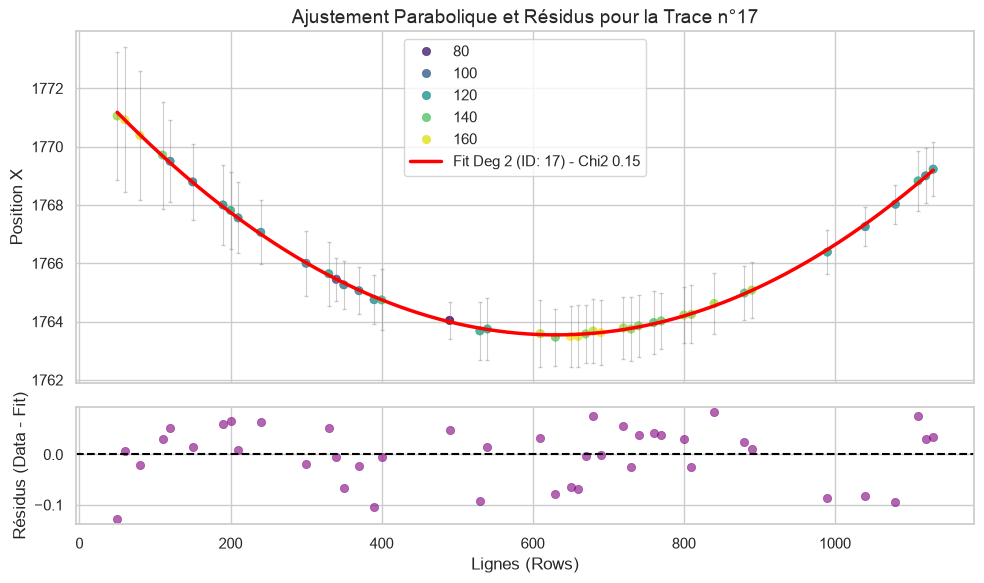

In [44]:
available_ids = list(fits.keys())
print(f'Available ids = {available_ids}')
if available_ids:
    target_id = available_ids[5]  # On prend la première parabole par exemple
    plot_track_and_residuals(fits, target_id)
# else:
#     print("Aucune trace n'a plus de 40 points dans vos données.")

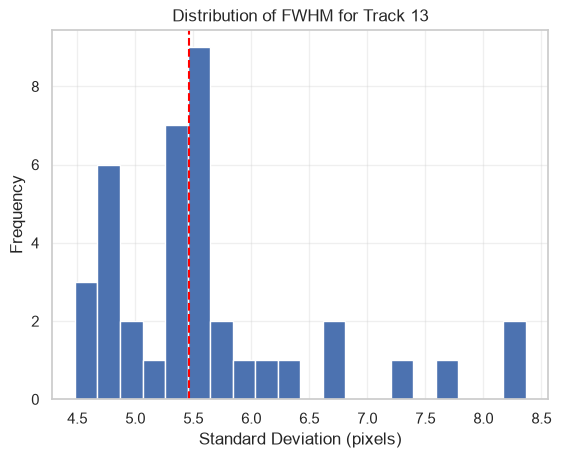

In [45]:
# Extract sigma values for the chosen target_id
target_id = available_ids[2]
if target_id in fits:
    coeffs, rows_t, x_t, insty, chi2_norm, std, noise = fits[target_id]
    FWHM = 2*np.sqrt(2*np.log(2))*std
    plt.hist(FWHM, bins=20)
    plt.axvline(np.median(FWHM),ls='--',color='red')
    plt.xlabel('Standard Deviation (pixels)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of FWHM for Track {target_id}')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"Track ID {target_id} not found in fits dictionary")



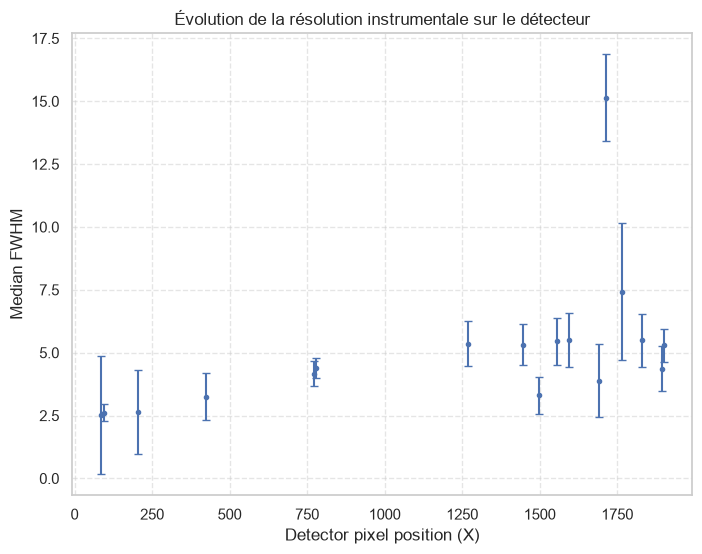

In [63]:
FWHM_med = np.zeros_like(available_ids, dtype=float)
FWHM_pos = np.zeros_like(available_ids, dtype=float)
FWHM_std = np.zeros_like(available_ids, dtype=float)
FWHM_id = np.zeros_like(available_ids, dtype=float)

for i, target_id in enumerate(available_ids):
    coeffs, rows_t, x_t, insty, chi2_norm, std, noise = fits[target_id]
    FWHM = 2*np.sqrt(2*np.log(2))*std
    FWHM_pos[i] = np.median(x_t)
    FWHM_med[i] = np.median(FWHM)
    FWHM_std[i] = np.std(FWHM)
    FWHM_id[i] = target_id

fig, ax = plt.subplots(figsize=(8,6))
ax.set_ylabel('Median FWHM')
ax.set_xlabel('Detector pixel position (X)')
ax.set_title("Évolution de la résolution instrumentale sur le détecteur")
ax.grid(True, linestyle="--", alpha=0.5)
ax.errorbar(x=FWHM_pos, y=FWHM_med,yerr=FWHM_std,ls='',marker='.',capsize=3)#,label=f'{target_id}')
# ax.legend()
plt.show()

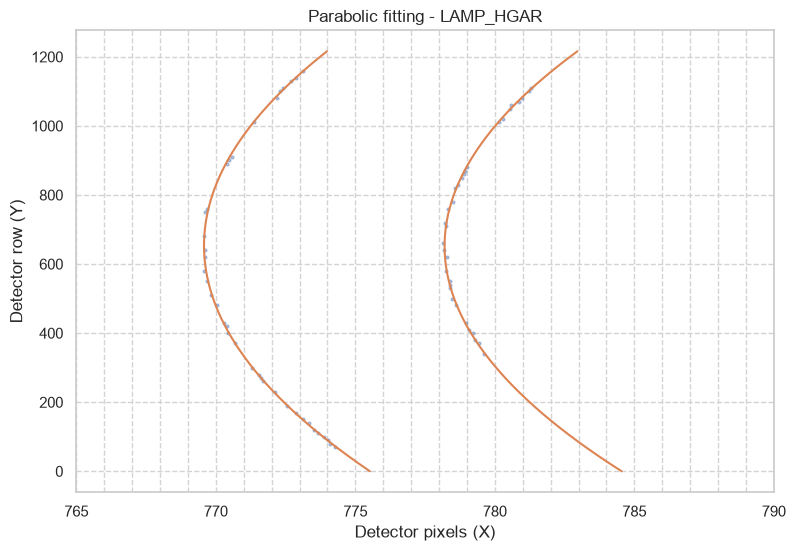

In [47]:
fig, ax = plt.subplots(figsize=(9,6))
import matplotlib.ticker as ticker

for tid, (coeffs, rows_t, x_t, insty, chi2, std,noise) in fits.items():
    # sc = ax.scatter(x_t, rows_t, c=np.log10(insty), s=12, cmap='viridis', alpha=0.5)
    sc = ax.plot(x_t, rows_t,'.', ms=4, alpha=0.4)
    row_fine = np.linspace(0, MAX_H, MAX_H+1)
    x_fit = np.polyval(coeffs, row_fine)
    ax.plot(x_fit, row_fine, '-', lw=1.5, label=f'raie {tid}')

ax.grid(ls='--',c='lightgrey',which='both')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Parabolic fitting - {OBJECT_NAME}")
ax.set_xlim(765,790)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
# ax.legend(fontsize=7)
plt.show()
# cbar = fig.colorbar(sc, ax=ax, label='log10(Intensity)')


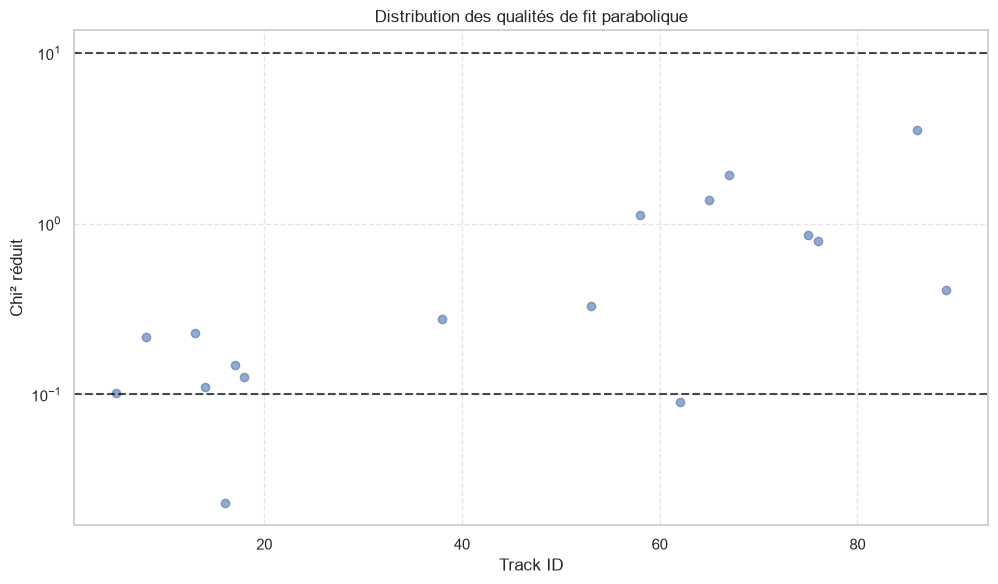

Chi² moyen : 0.686
Chi² médian : 0.276
Chi² min/max : 0.023 / 3.524


In [48]:
# Extraire tous les chi2 et les track_ids
track_ids = list(fits.keys())
chi2_values = [fits[tid][4] for tid in track_ids]  # fits[tid][4] = chi2_norm

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(track_ids, chi2_values, alpha=0.6)
plt.xlabel('Track ID')
plt.ylabel('Chi² réduit')
plt.title('Distribution des qualités de fit parabolique')
plt.axhline(y=0.1,ls='--',c='black',alpha=0.7)
plt.axhline(y=10,ls='--',c='black',alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.yscale('log')
plt.show()

# Stats
print(f"Chi² moyen : {np.mean(chi2_values):.3f}")
print(f"Chi² médian : {np.median(chi2_values):.3f}")
print(f"Chi² min/max : {np.min(chi2_values):.3f} / {np.max(chi2_values):.3f}")

In [49]:
# import numpy as np

# # Calcule et trace SNR (prominence / noise) POUR UNE LIGNE SÉLECTIONNÉE
# selected_row = 420  # change si besoin

# track_ids_row = []
# proms = []
# noises = []
# snr = []
# x_positions = []

# for tid, pts in tracks.items():
#     pts_arr = np.array(pts)
#     # chaque pt : (row, p, prom, sig, noise, alpha) dans ton pipeline
#     mask = pts_arr[:, 0] == selected_row
#     if np.any(mask):
#         entry = pts_arr[mask][0]
#         prom = float(entry[2])
#         # noise is at index 4 according to the tuple layout; guard against missing/NaN
#         try:
#             noise = float(entry[])
#             if not np.isfinite(noise):
#                 noise = np.nan
#         except Exception:
#             noise = np.nan

#         if noise == 0 or np.isnan(noise):
#             s = np.nan
#         else:
#             s = prom / noise
#         track_ids_row.append(tid)
#         proms.append(prom)
#         noises.append(noise)
#         snr.append(s)
#         x_positions.append(float(entry[1]))

# import matplotlib.pyplot as plt

# if len(track_ids_row) == 0:
#     print(f"Aucun pic trouvé à la ligne {selected_row}")
# else:
#     plt.figure(figsize=(10,5))
#     plt.scatter(x_positions, snr, c='C0', alpha=0.8)
#     for i, tid in enumerate(track_ids_row):
#         plt.text(x_positions[i], snr[i], str(tid), fontsize=8, ha='left', va='bottom')
#     plt.xlabel('Position X (pixel)')
#     plt.ylabel('SNR = prominence / noise')
#     plt.title(f'SNR des raies sur la ligne {selected_row}')
#     plt.yscale('log')
#     plt.grid(True, ls='--', alpha=0.4)
#     plt.tight_layout()
#     plt.show()

#     print("track_ids :", track_ids_row)
#     print("prominences :", proms)
#     print("noises :", noises)
#     print("SNR :", snr)

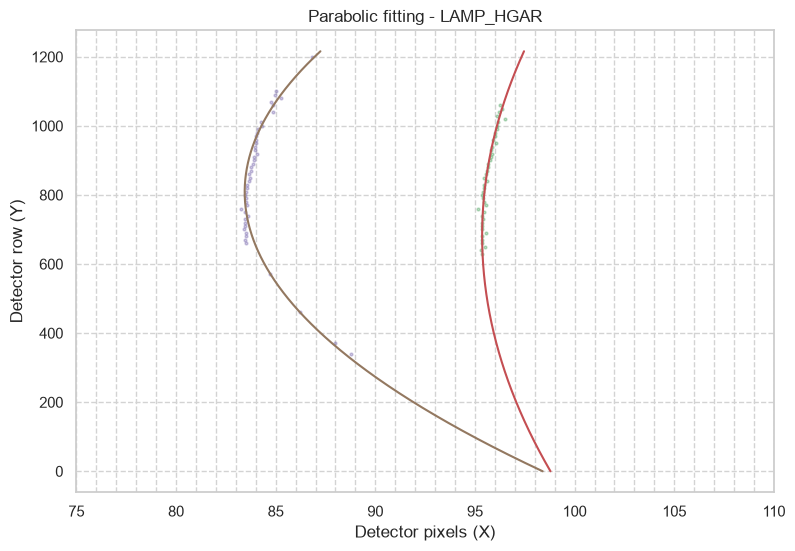

In [50]:
fig, ax = plt.subplots(figsize=(9,6))
import matplotlib.ticker as ticker

for tid, (coeffs, rows_t, x_t, insty, chi2,std,noise) in fits.items():
    # sc = ax.scatter(x_t, rows_t, c=np.log10(insty), s=12, cmap='viridis', alpha=0.5)
    sc = ax.plot(x_t, rows_t,'.', ms=4, alpha=0.4)
    row_fine = np.linspace(0, MAX_H, MAX_H+1)
    x_fit = np.polyval(coeffs, row_fine)
    ax.plot(x_fit, row_fine, '-', lw=1.5, label=f'raie {tid}')

ax.grid(ls='--',c='lightgrey',which='both')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Parabolic fitting - {OBJECT_NAME}")
# ax.set_xlim(765,790) # doublet mercure
ax.set_xlim(75,110)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
# ax.legend(fontsize=7)
plt.show()
# cbar = fig.colorbar(sc, ax=ax, label='log10(Intensity)')


L'ordre exact de tes raies de gauche à droite est : [67, 89, 65, 58, 5, 62, 8, 53, 38, 13, 14, 75, 16, 17, 18, 86, 76]


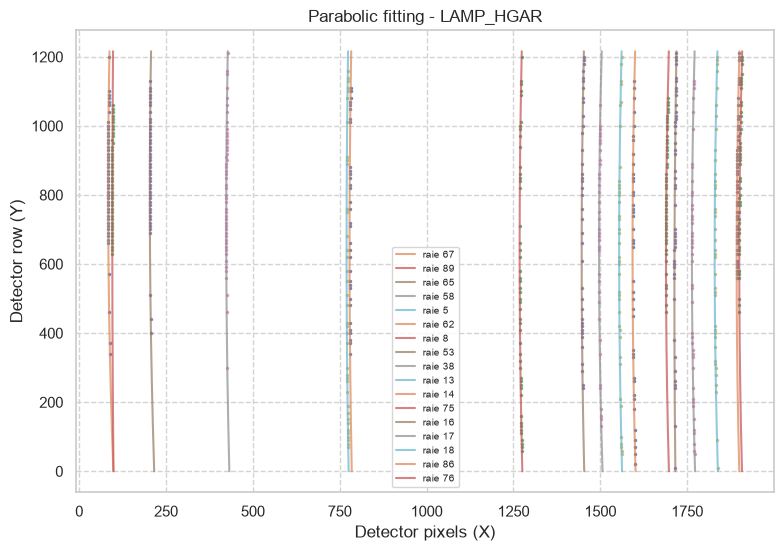

In [51]:
fig, ax = plt.subplots(figsize=(9,6))
import matplotlib.ticker as ticker
# 1. On trie le dictionnaire de gauche à droite
fits_sorted = dict(sorted(fits.items(), key=lambda item: np.median(item[1][2])))

# 2. On regarde l'ordre RÉEL des IDs sur ton écran
print("L'ordre exact de tes raies de gauche à droite est :", list(fits_sorted.keys()))
for tid, (coeffs, rows_t, x_t, insty, chi2,std,noise) in fits_sorted.items():
    # sc = ax.scatter(x_t, rows_t, c=np.log10(insty), s=12, cmap='viridis', alpha=0.5)
    sc = ax.plot(x_t, rows_t,'.', ms=3, alpha=0.8,zorder=1)
    row_fine = np.linspace(0, MAX_H, MAX_H+1)
    x_fit = np.polyval(coeffs, row_fine)
    ax.plot(x_fit, row_fine, '-',lw=1.5, label=f'raie {tid}',alpha=0.7,zorder=2)

ax.grid(ls='--',c='lightgrey',which='both')
ax.set_xlabel('Detector pixels (X)')
ax.set_ylabel('Detector row (Y)')
ax.set_title(f"Parabolic fitting - {OBJECT_NAME}")
# ax.set_xlim(765,790) # doublet mercure
# ax.set_xlim(75,110)
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.legend(fontsize=7)
plt.show()
# cbar = fig.colorbar(sc, ax=ax, label='log10(Intensity)')


1936


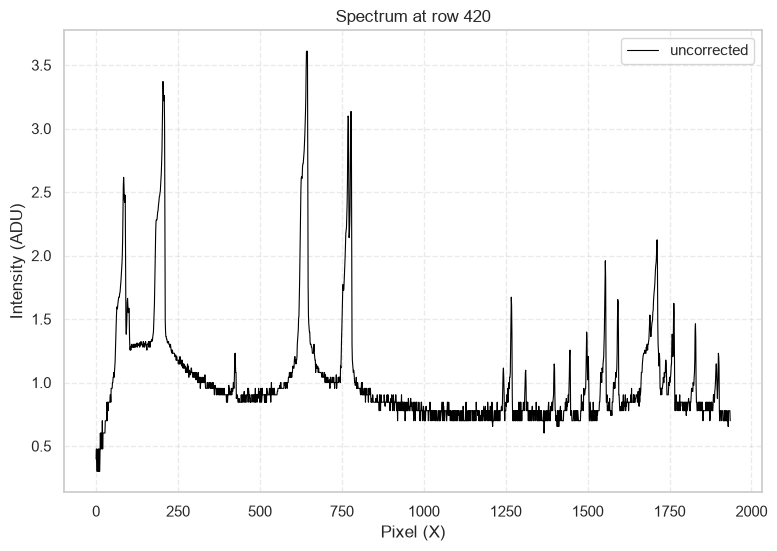

In [52]:
# change this to the detector row you want to inspect
selected_row = 420

# extract spectra (reverse X as in notebook convention)
x = np.arange(MAX_W)
print(MAX_W)
spec_uncorr = MASTER_SCIENCE_UNCORR[selected_row, :][::-1]
# spec_corr   = MASTER_SCIENCE[selected_row, :][::-1]

# find peaks on the uncorrected spectrum (adjust params if needed)
# peaks, props = find_peaks(spec_uncorr, prominence=5, distance=5)

# plot
plt.figure(figsize=(9,6))
plt.plot(x, np.log10(spec_uncorr), color='black', lw=0.8, label='uncorrected')
# plt.plot(x, spec_corr,   color='tab:blue', lw=0.8, ls='--', label='corrected')
# plt.scatter(peaks, spec_uncorr[peaks], marker='x', color='red', label='peaks')
plt.title(f"Spectrum at row {selected_row}")
plt.xlabel("Pixel (X)")
plt.ylabel("Intensity (ADU)")
# plt.xlim(0, MAX_W)
# plt.gca().xaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.grid(ls='--', alpha=0.4,which='both')
# plt.xlim(70,100)
plt.legend()
plt.show()

---

## **8. Wavelength/pixel mapping**

In [53]:
list(fits_sorted.keys())

[67, 89, 65, 58, 5, 62, 8, 53, 38, 13, 14, 75, 16, 17, 18, 86, 76]

In [54]:
# wave_hg = [404.64,407.8,491.62,546.06,567.7,576.96,579.07,614.86,671.54,690.74,703.3,748.88,773,774.4]
# wave_hg = [404.64,407.8,491.62,546.06,567.7,576.96,579.07,614.86,671.54,690.74,703.3]#,748.88]#,773,774.4]
# À adapter avec TES vrais IDs et les raies correspondantes :
fits_sorted = dict(sorted(fits.items(), key=lambda item: np.median(item[1][2])))

# 2. Ton catalogue actuel (5 raies)

longueurs_onde_triees = [
    404.66,  # Correspondra à la 1ère raie tout à gauche (ex: ID 30)
    407.78,  # Correspondra à la 2ème raie
    435.83,
    491.60,  # Correspondra à la 3ème raie
    # 546.07,  # ...
    576.96,
    579.07,

    696.543,

    738.393,
    750.387,
    763.511,
    772.376,

    794.818,
    800.616,
    # 801.479,
    810.369,
    # 811.531,

    826.452,
    840.820,
    842.465
    # 615,
    # 623.5,
    # 671.56,
    # 690.74,
    # 772.88
    # 734,
    # 585.20,
    # 588.20,
    # 603.00   # Correspondra à la 9ème raie tout à droite
]


raies_physiques = {}
for i, key in enumerate(fits_sorted.keys()):
    raies_physiques[key] = longueurs_onde_triees[i]


In [55]:
degre_calib = 3  # Polynôme de degré 2 pour la relation Pixel X -> Lambda

# Matrice pour stocker les coefficients (a, b, c) pour CHAQUE ligne Y du CCD
calib_matrix = np.zeros((int(MAX_H) + 1, degre_calib + 1))

# On définit nos variables de référence pour le fit à partir du dictionnaire trié
valid_tids = list(fits_sorted.keys())
true_wavelengths = np.array([raies_physiques[tid] for tid in valid_tids]) 
# (Note : true_wavelengths est maintenant identique à longueurs_onde_triees, mais dans l'ordre des tids)

# Boucle sur toutes les lignes (rows) du détecteur (axe Y)
for row in range(int(MAX_H) + 1):
    x_at_row = []
    
    # Pour la ligne actuelle, on évalue la position X théorique de chaque raie
    for tid in valid_tids:
        coeffs_track = fits_sorted[tid][0]  # On utilise bien le dictionnaire trié
        x_val = np.polyval(coeffs_track, row)
        x_at_row.append(x_val)
        
    x_at_row = np.array(x_at_row)
    
    # LE CALCUL CLÉ : on cherche la fonction Lambda = f(X) pour CETTE ligne précise
    coeffs_calib = np.polyfit(x_at_row, true_wavelengths, deg=degre_calib)
    
    # On sauvegarde les coefficients du polynôme pour cette ligne Y
    calib_matrix[row, :] = coeffs_calib

print("Calibration 2D terminée avec succès ! 🎉")

Calibration 2D terminée avec succès ! 🎉


<>:21: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:21: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_32898/1914573613.py:21: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  cbar.set_label("Longueur d'onde $\lambda$ (nm)", fontsize=12)


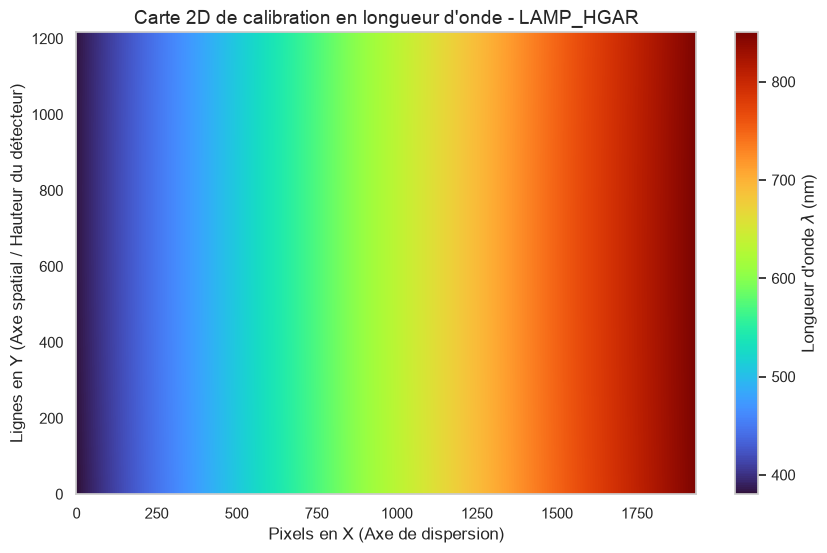

In [69]:
import matplotlib.pyplot as plt

# Définis la largeur de ton image en pixels (axe X)
# MAX_W = 2048  # Modifie cette valeur selon la largeur réelle de ton CCD

x_pixels = np.arange(0, MAX_W)
wavelength_map_2D = np.zeros((int(MAX_H) + 1, MAX_W))

# On remplit la matrice 2D en évaluant le polynôme pour chaque ligne
for row in range(int(MAX_H) + 1):
    wavelength_map_2D[row, :] = np.polyval(calib_matrix[row], x_pixels)

# --- Affichage du Plot 2D ---
plt.figure(figsize=(10, 6))
plt.grid(False)
# 'turbo' ou 'jet' sont parfaits pour les spectres car ils vont du violet au rouge
img = plt.imshow(wavelength_map_2D, aspect='auto', cmap='turbo', origin='lower')

# Ajout de la barre de légende des couleurs
cbar = plt.colorbar(img)
cbar.set_label("Longueur d'onde $\lambda$ (nm)", fontsize=12)

plt.xlabel("Pixels en X (Axe de dispersion)", fontsize=12)
plt.ylabel("Lignes en Y (Axe spatial / Hauteur du détecteur)", fontsize=12)
plt.title(f"Carte 2D de calibration en longueur d'onde - {OBJECT_NAME}", fontsize=14)
plt.show()

<>:46: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:46: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_32898/1074206282.py:46: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax1.set_ylabel("Longueur d'onde $\lambda$ (nm)", fontsize=11)


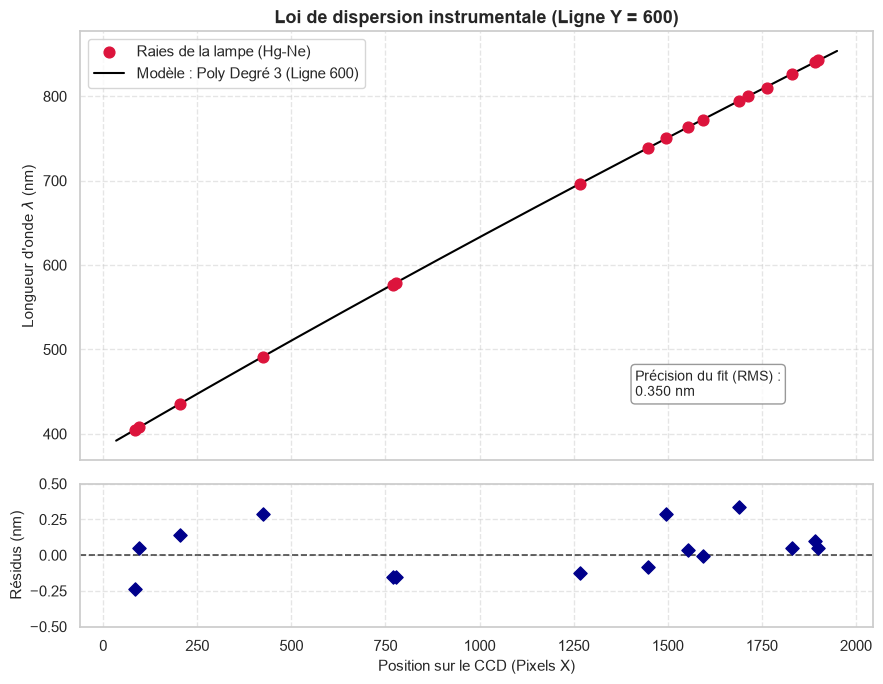

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CHOIX DE LA LIGNE À INSPECTER
# ==========================================
ligne_choisie = 600  # Tu peux changer cette valeur (ex: 0, 500, 1000...)

# ==========================================
# 2. EXTRACTION DES DONNÉES POUR CETTE LIGNE
# ==========================================
x_mesure = []

# On récupère la position X de chaque raie à la ligne choisie
for tid in valid_tids:
    coeffs_track = fits_sorted[tid][0]
    x_val = np.polyval(coeffs_track, ligne_choisie)
    x_mesure.append(x_val)

x_mesure = np.array(x_mesure)

# On récupère les coefficients de calibration calculés pour cette ligne précise
coeffs_calib_ligne = calib_matrix[ligne_choisie]

# On crée une grille fine de pixels en X pour tracer une courbe de fit bien lisse
x_fit_continu = np.linspace(x_mesure.min() - 50, x_mesure.max() + 50, 1000)
wl_fit_continu = np.polyval(coeffs_calib_ligne, x_fit_continu)

# Calcul des positions prédites pour le calcul des résidus
wl_predit = np.polyval(coeffs_calib_ligne, x_mesure)
residus = true_wavelengths - wl_predit
rms = np.sqrt(np.mean(residus**2)) # Erreur quadratique moyenne (RMS)

# ==========================================
# 3. TRACÉ DU GRAPHIQUE (FIT + RÉSIDUS)
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Panneau Supérieur : Le Fit Polynomial ---
ax1.scatter(x_mesure, true_wavelengths, color='crimson', marker='o', s=60, 
            label='Raies de la lampe (Hg-Ne)', zorder=3)
ax1.plot(x_fit_continu, wl_fit_continu, color='black', lw=1.5, 
         label=f'Modèle : Poly Degré {degre_calib} (Ligne {ligne_choisie})')

ax1.set_ylabel("Longueur d'onde $\lambda$ (nm)", fontsize=11)
ax1.set_title(f"Loi de dispersion instrumentale (Ligne Y = {ligne_choisie})", fontsize=13, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# Ajout d'une petite boîte de texte avec la précision du fit (RMS)
text_perf = f"Précision du fit (RMS) :\n{rms:.3f} nm"
ax1.text(0.70, 0.15, text_perf, transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# --- Panneau Inférieur : Les Résidus ---
ax2.scatter(x_mesure, residus, color='darkblue', marker='D', s=45, zorder=3, label='Écarts')
ax2.axhline(0, color='black', linestyle='--', lw=1.2, alpha=0.7) # Ligne zéro idéal

ax2.set_xlabel("Position sur le CCD (Pixels X)", fontsize=11)
ax2.set_ylabel("Résidus (nm)", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(-0.5, 0.5) # Ajuste les limites si tes résidus sont plus grands

# Ajustement de la disposition
plt.tight_layout()
plt.show()

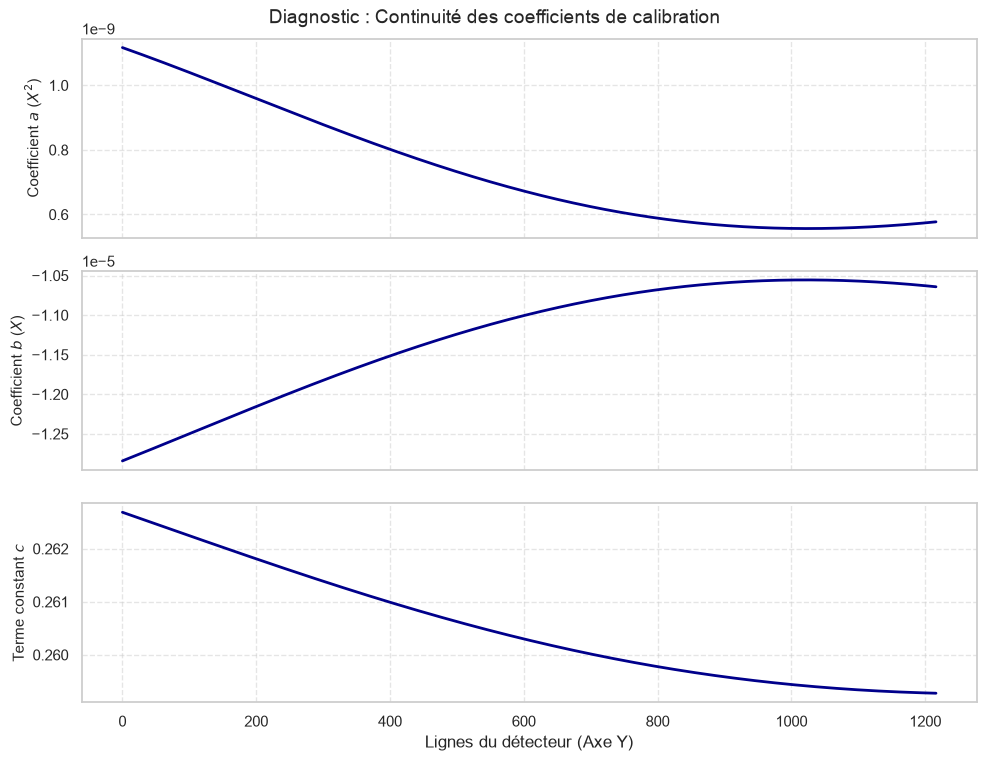

In [71]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

lignes_Y = np.arange(0, int(MAX_H) + 1)
noms_coefs = ["Coefficient $a$ ($X^2$)", "Coefficient $b$ ($X$)", "Terme constant $c$"]

for i in range(3):
    axes[i].plot(lignes_Y, calib_matrix[:, i], color='darkblue', lw=2)
    axes[i].set_ylabel(noms_coefs[i], fontsize=11)
    axes[i].grid(ls='--', alpha=0.5)

axes[2].set_xlabel("Lignes du détecteur (Axe Y)", fontsize=12)
fig.suptitle("Diagnostic : Continuité des coefficients de calibration", fontsize=14, y=0.95)
plt.tight_layout()
plt.show()

<>:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_32898/4130733529.py:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel("Longueur d'onde $\lambda$ (nm)", fontsize=12)


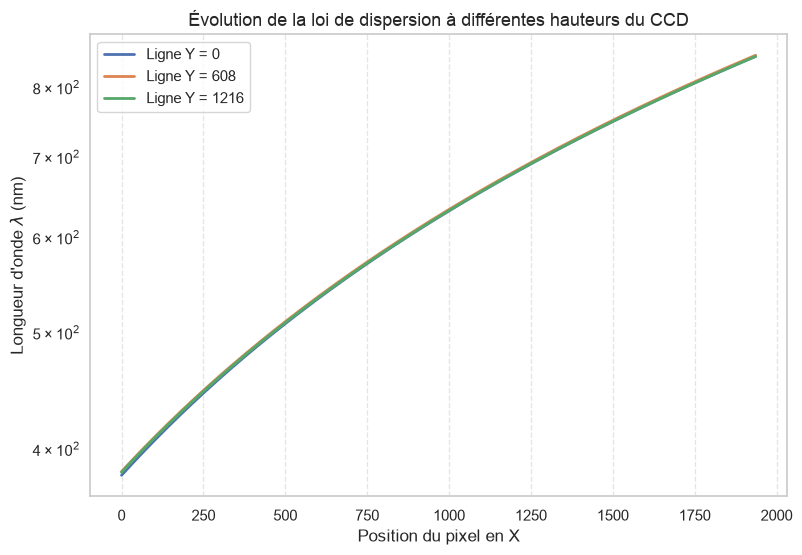

In [72]:
# Choix de quelques lignes représentatives à inspecter
rows_to_check = [0, int(MAX_H) // 2, int(MAX_H)]
x_fine = np.linspace(0, MAX_W, 500)

plt.figure(figsize=(9, 6))

for r in rows_to_check:
    # On évalue la loi de dispersion de la ligne 'r'
    wl_fine = np.polyval(calib_matrix[r], x_fine)
    plt.plot(x_fine, wl_fine, lw=2, label=f"Ligne Y = {r}")

plt.xlabel("Position du pixel en X", fontsize=12)
plt.ylabel("Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.title("Évolution de la loi de dispersion à différentes hauteurs du CCD", fontsize=13)
plt.legend()
plt.yscale("log")
plt.grid(ls='--', alpha=0.5)
plt.show()

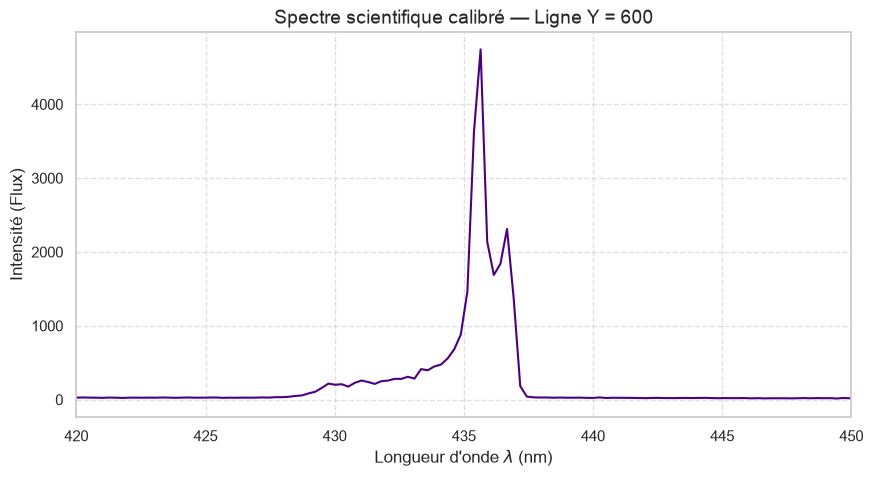

In [108]:
import matplotlib.pyplot as plt

# 1. Tu choisis la ligne Y qui t'intéresse 
# (par exemple là où le signal de ton objet scientifique est le plus intense)
y_choisi = 600 

# 2. Tu extrais le flux scientifique et les longueurs d'onde associées
flux_ligne = MASTER_SCIENCE[y_choisi, :][::-1]
lambdas_ligne = wavelength_map_2D[y_choisi, :] # Ta carte magique !

# 3. Le plot magique
plt.figure(figsize=(10, 5), dpi=100)
plt.plot(lambdas_ligne, flux_ligne, color='indigo', lw=1.5)

# Les labels changent enfin de dimension !
plt.xlabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.ylabel("Intensité (Flux)", fontsize=12)
plt.title(f"Spectre scientifique calibré — Ligne Y = {y_choisi}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(420,450)
plt.show()

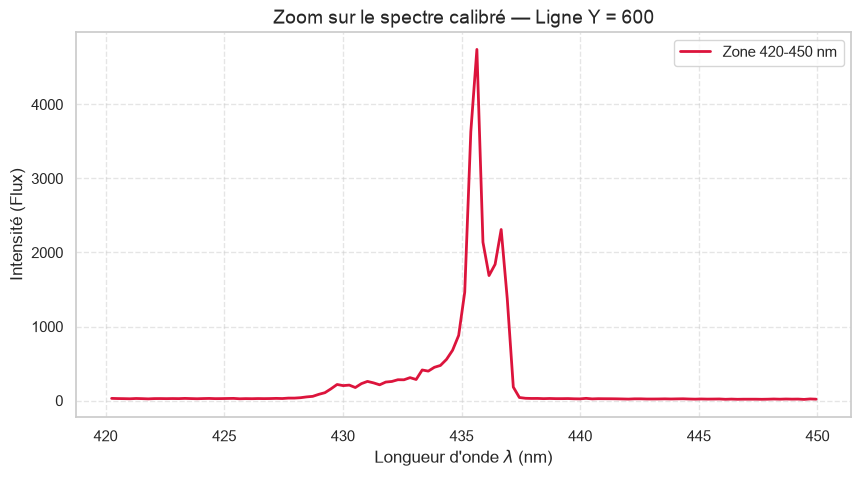

In [109]:
LAMBDA_MIN = 420
LAMBDA_MAX = 450

masque_zone = (lambdas_ligne >= LAMBDA_MIN) & (lambdas_ligne <= LAMBDA_MAX)

lambdas_zoom = lambdas_ligne[masque_zone]
flux_zoom = flux_ligne[masque_zone]

# 5. Affichage du spectre zoomé
plt.figure(figsize=(10, 5), dpi=100)
plt.plot(lambdas_zoom, flux_zoom, color='crimson', lw=2, label=f'Zone {LAMBDA_MIN}-{LAMBDA_MAX} nm')

# Un peu de cosmétique
plt.xlabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.ylabel("Intensité (Flux)", fontsize=12)
plt.title(f"Zoom sur le spectre calibré — Ligne Y = {y_choisi}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

In [110]:
# 1. Nouveau modèle : Deux gaussiennes + fond constant
def deux_gaussiennes(x, amp1, mu1, sigma1, amp2, mu2, sigma2, bg):
    g1 = amp1 * np.exp(-((x - mu1) ** 2) / (2 * sigma1**2))
    g2 = amp2 * np.exp(-((x - mu2) ** 2) / (2 * sigma2**2))
    return g1 + g2 + bg

In [113]:
# 3. Préparation des suppositions initiales (p0) automatiques
amp_guess = np.max(flux_zoom) - np.min(flux_zoom)  # Hauteur du pic
mu_guess = lambdas_zoom[np.argmax(flux_zoom)]  # Position du pic
sigma_guess = 0.5  # Largeur type d'une raie en nm (à ajuster au besoin)
bg_guess = np.min(flux_zoom)  # Le fond continu le plus bas

# p0 = [amp_guess, mu_guess, sigma_guess, 7, bg_guess]

# # 4. Le Curve Fit !
# # popt contient les paramètres optimaux [amp, mu, sigma, bg]
# # pcov contient la matrice de covariance (pour calculer les barres d'erreur)
# popt, pcov = curve_fit(asymGaussian, lambdas_zoom, flux_zoom, p0=p0)

# 2. Des suppositions initiales (p0) CHIRURGICALES
# Pour un fit multi-pics, curve_fit a BESOIN d'être guidé à la main au départ !
p0 = [
    3500,
    435,
    0.6,  # Pic principal (Amp, Mu, Sigma) -> d'après ton graphique
    300,
    436.0,
    1.5,  # Bosselage secondaire (Amp, Mu, Sigma) -> d'après ton graphique
    50,  # Fond continu (bg)
]

# 3. Le Curve Fit avec des bornes (Bounds) pour éviter que le code devienne fou
# format : ([min_amp1, min_mu1, ...], [max_amp1, max_mu1, ...])
bornes_inf = [2000, 434.0, 0.1, 50, 428.0, 0.5, 0]
bornes_sup = [5000, 437.0, 2.0, 1000, 433.0, 4.0, 200]

popt, pcov = curve_fit(
    deux_gaussiennes, lambdas_zoom, flux_zoom, p0=p0, bounds=(bornes_inf, bornes_sup)
)

# Extraction des résultats
# amp_opt, mu_opt, sigma_opt, alpha_opt, bg_opt = popt
amp1_opt, mu1_opt, sigma1_opt, amp2_opt, mu2_opt, sigma2_opt, bg_opt = popt

# Extraction des incertitudes associées (depuis pcov)
perr = np.sqrt(np.diag(pcov))
amp1_err, mu1_err, sigma1_err, amp2_err, mu2_err, sigma2_err, bg_err = perr

# incertitudes = np.sqrt(np.diag(pcov))  # Erreur type sur chaque paramètre

# 5. Générer une courbe lisse pour le fit
lambdas_fit = np.linspace(LAMBDA_MIN, LAMBDA_MAX, 500)
flux_fit = deux_gaussiennes(lambdas_fit, *popt)#asymGaussian(lambdas_fit, *popt)

# ==========================================
# AFFICHAGE
# ==========================================
plt.figure(figsize=(10, 5), dpi=100)

# Plot des données réelles (les pixels de la zone)
plt.scatter(
    lambdas_zoom,
    flux_zoom,
    color='black',
    alpha=0.6,
    label='Données (Pixels)',
    zorder=3,
)

# Plot de la belle courbe ajustée
plt.plot(
    lambdas_fit,
    flux_fit,
    color='crimson',
    lw=2.5,
    label=fr'Fit Gaussien ($\mu$ = {mu1_opt:.3f}±{mu1_err:.3f} nm)',
)

plt.xlabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.ylabel("Intensité", fontsize=12)
plt.title("Ajustement d'un profil de raie par Curve Fit", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Affichage des résultats scientifiques dans la console
print(f"--- RÉSULTATS DU FIT ---")
print(fr"Centre exact de la raie ($\mu$) : {mu_opt:.4f} ± {incertitudes[1]:.4f} nm")
print(f"Amplitude du pic : {amp_opt:.2f} au-dessus du fond")
print(f"Largeur à mi-hauteur (FWHM) : {2.355 * sigma_opt:.4f} nm")

ValueError: Initial guess is outside of provided bounds

### SNR Plot

-----

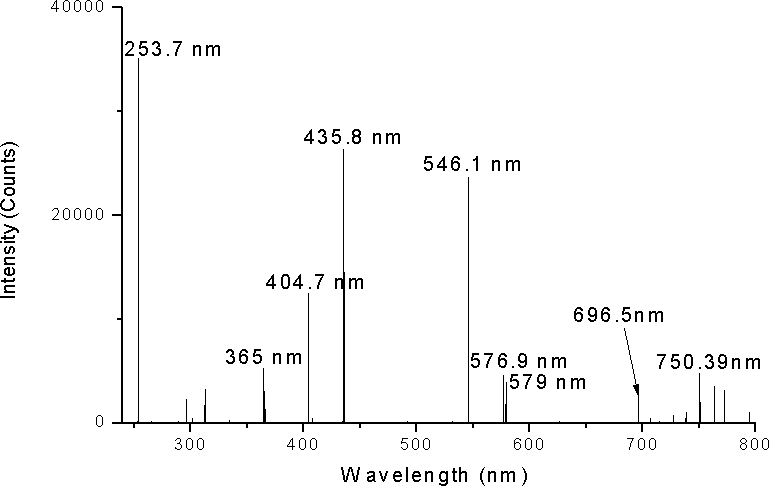

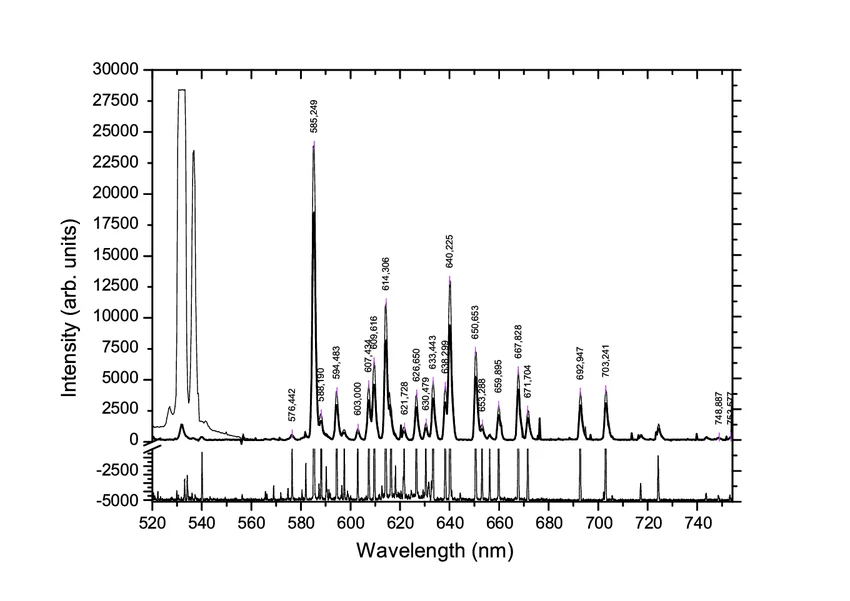

| Raie | Longueur d’onde (nm) | Élément associé | Couleur |
|---|---:|---|---|
| 404.656 | 404.656 | Hg | bleu |
| 407.781 | 407.781 | Hg | bleu |
| 435.835 | 435.835 | Hg | bleu |
| 491.604 | 491.604 | Hg | bleu |
| 546.074 | 546.074 | Hg | vert |
| 576.959 | 576.959 | Hg | jaune-orangé |
| 579.065 | 579.065 | Hg | jaune-orangé |
| 540.1 | 540.1 | Ne | vert |
| 585.2 | 585.2 | Ne | jaune |
| 588.2 | 588.2 | Ne | jaune |
| 603.0 | 603.0 | Ne | orange |
| 607.4 | 607.4 | Ne | orange |
| 616.4 | 616.4 | Ne | orange |
| 621.7 | 621.7 | Ne | rouge-orangé |
| 626.6 | 626.6 | Ne | rouge-orangé |
| 633.4 | 633.4 | Ne | rouge |
| 638.3 | 638.3 | Ne | rouge |
| 640.2 | 640.2 | Ne | rouge |
| 650.6 | 650.6 | Ne | rouge |
| 659.9 | 659.9 | Ne | rouge |
| 692.9 | 692.9 | Ne | rouge |
| 703.2 | 703.2 | Ne | rouge |

**Remarque :** les raies à 404.656, 407.781, 435.835, 491.604, 546.074, 576.959 et 579.065 nm sont généralement attribuées au mercure, tandis que les autres correspondent au néon.
red